In [ ]:
%run scripts/verify_environment.py

verify_environment()

In [ ]:
from getpass import getpass

admin_rdm_url = 'https://admin.bh.rdm.yzwlab.com/' # 'https://admin.staging.rdm.example.com'
idp_name_project_limit_1 = None
institution_name_project_limit_1 = None

# 統合管理者用 (manager)
idp_name_integrated_admin = None
idp_username_integrated_admin = None
idp_password_integrated_admin = None

default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [ ]:
if idp_name_project_limit_1 is None:
    idp_name_project_limit_1 = input(prompt=f'IdP Name: ')
    
if institution_name_project_limit_1 is None:
    institution_name_project_limit_1 = input(prompt=f'Institution Name: ')
    
if idp_name_integrated_admin is None:
    idp_name_integrated_admin = input(prompt=f'IdP Name for integrated admin: ')
if idp_username_integrated_admin is None:
    idp_username_integrated_admin = input(prompt=f'Username for {idp_name_integrated_admin} (integrated admin)')
if idp_password_integrated_admin is None:
    idp_password_integrated_admin = getpass(prompt=f'Password for {idp_username_integrated_admin}@{idp_name_integrated_admin}')

In [ ]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

# プロジェクト制限数_ルール作成・変更・削除

- サブシステム名: プロジェクト制限数
- ページ/アドオン: ルール作成・変更・削除
- 機能分類: ルール
- シナリオ名: プロジェクト制限数のルール作成・変更・削除
- 用意するテストデータ: URL一覧、アカウント(統合管理者既存ユーザー: GRDM)

In [ ]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

## ウェブブラウザの新規プライベートウィンドウで GRDM 管理者トップページを表示する

GRDM 管理者トップページが表示されること

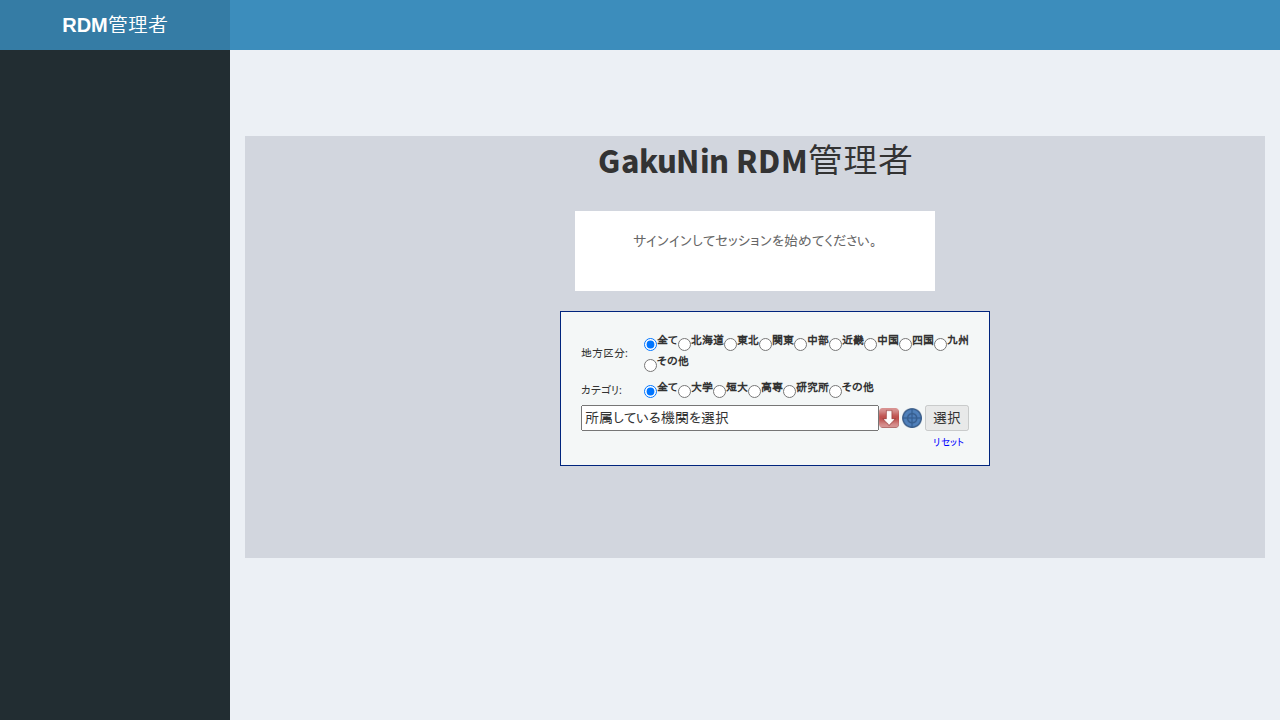

In [6]:
async def _step(page):
    await page.goto(admin_rdm_url)

    await expect(page.locator('.login-logo')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## アカウント(統合管理者既存ユーザー)を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。


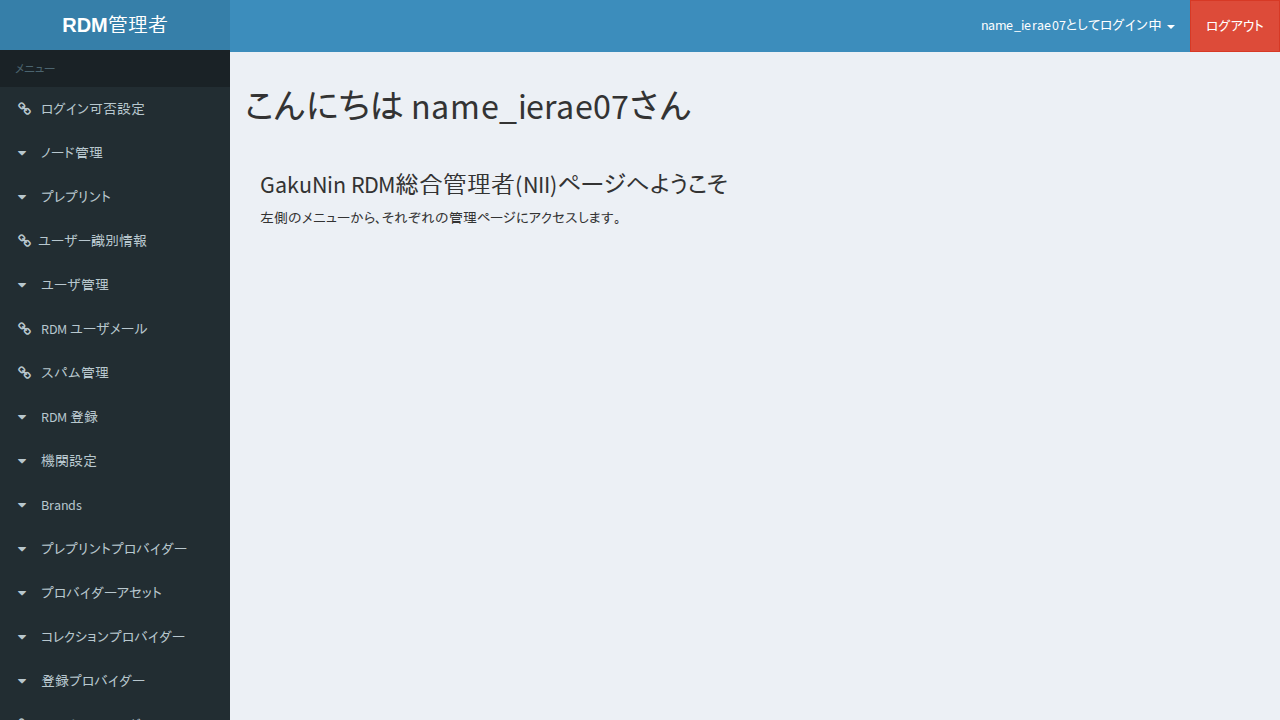

In [7]:
async def _step(page):
    await scripts.grdm.login_as_admin(
        page, idp_name_integrated_admin, idp_username_integrated_admin, idp_password_integrated_admin, transition_timeout=transition_timeout
    )

    await expect(page.locator('//*[contains(@class, "btn-danger") and contains(text(), "ログアウト")]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## メニューから「プロジェクト制限数」をクリックする

「設定テンプレート」「設定」のサブメニューが表示されること


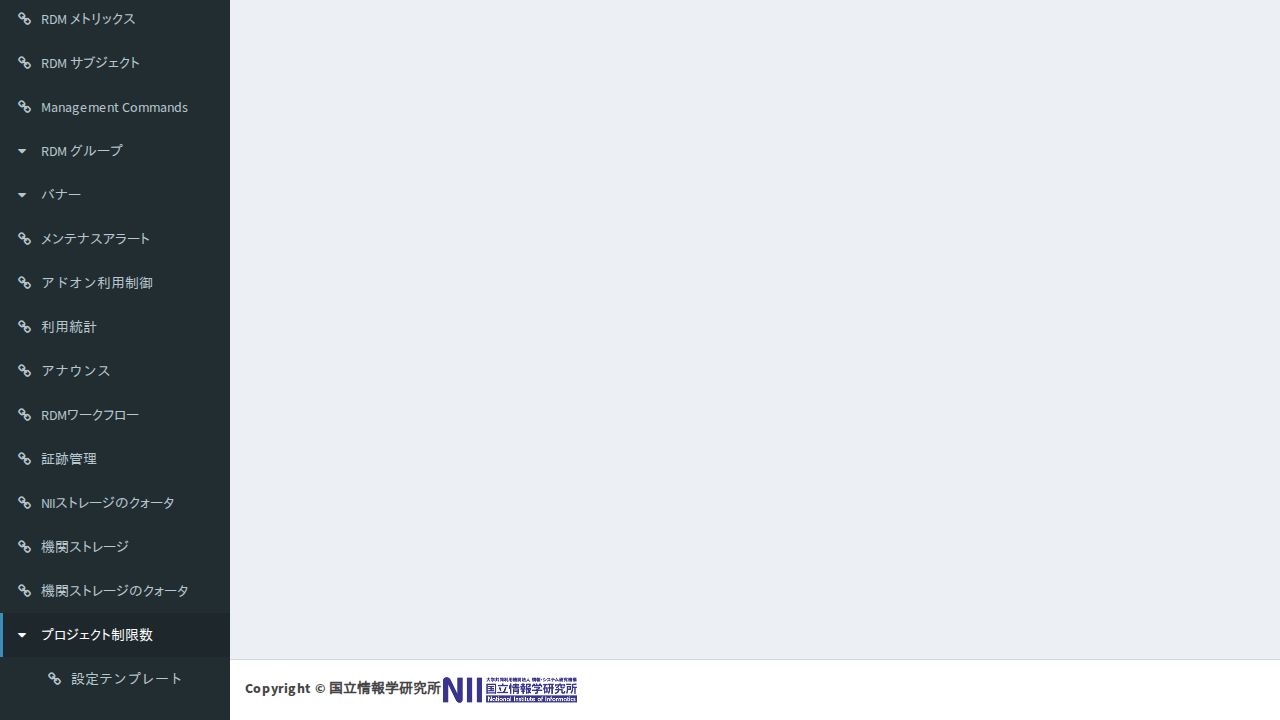

In [8]:
async def _step(page):
    await page.locator('//a[@href = "#collapseProjectLimitNumber"]').click()

    await expect(page.locator('//a[@href = "/project_limit_number/templates/"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//a[@href = "/project_limit_number/settings/"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## サブメニューから「設定」をクリックする

「プロジェクト作成数設定一覧」画面が表示されること


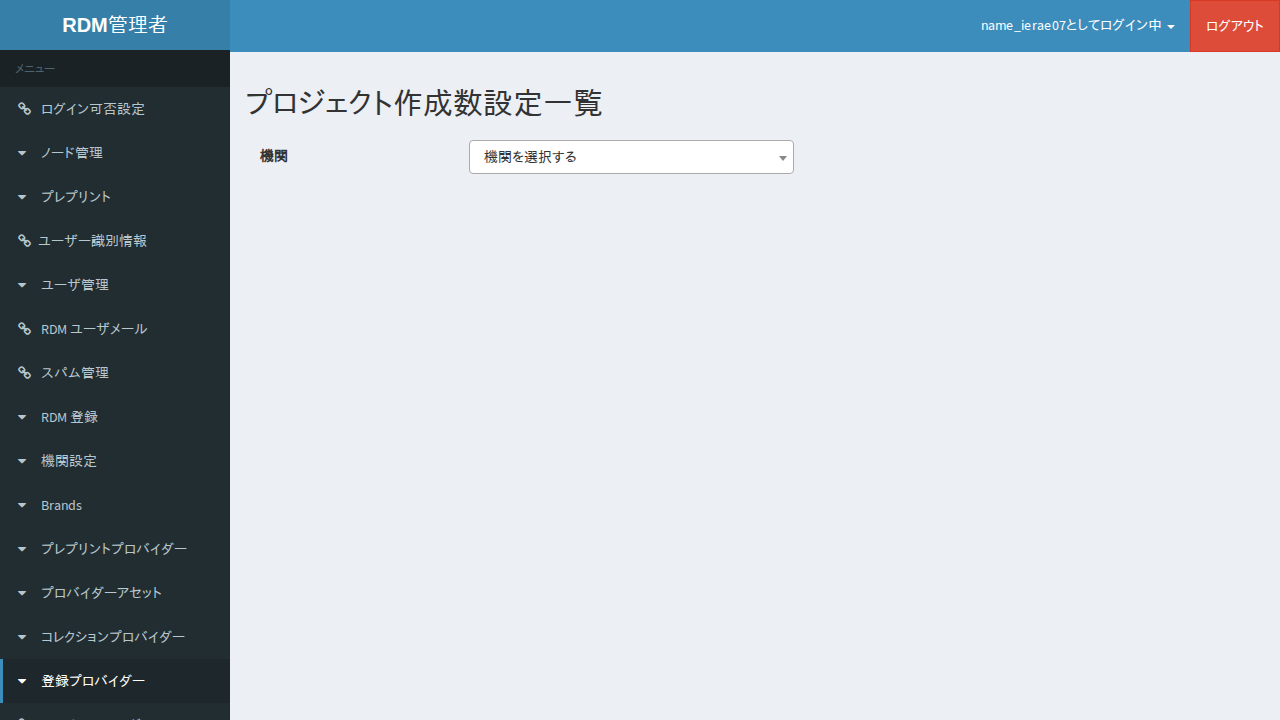

In [9]:
async def _step(page):
    await page.locator('//a[@href = "/project_limit_number/settings/"]').click()

    await expect(page.locator('//h2[text() = "プロジェクト作成数設定一覧"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「機関」の「機関を選択する」をクリックし、「テンプレート作成・変更・削除」シートのNo. 2 のユーザが所属する機関を選択する

「プロジェクト制限のデフォルト」以下の項目が表示されること


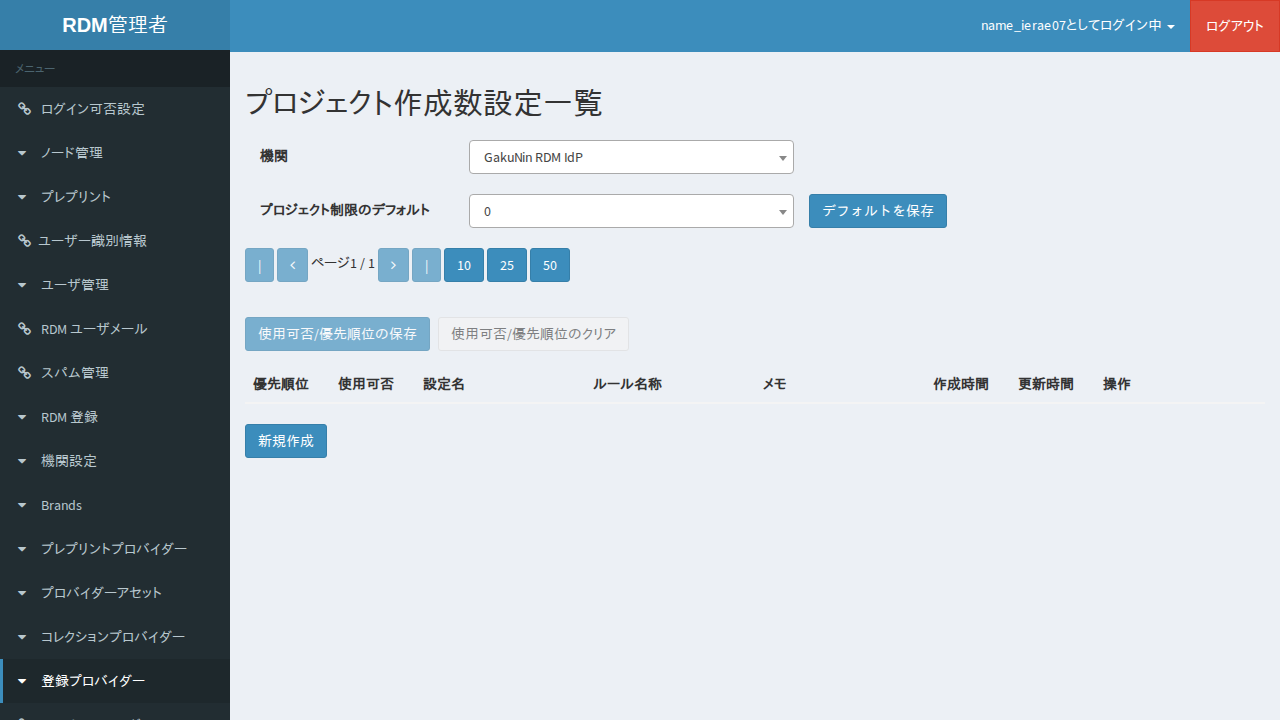

In [ ]:
async def _step(page):
    await page.locator('#institution_id').select_option(label=f'{institution_name_project_limit_1}')
    
    # 「プロジェクト制限のデフォルト」以下の項目が表示されることを確認
    await expect(page.locator('#project_limit_number_default_id')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('button', has_text='デフォルトを保存')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#save_changes_button')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#clear_changes_button')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#setting-table')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('a', has_text='新規作成')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクト制限のデフォルト」のドロップダウンリストをクリックする

「無制限」「0」「1」...とドロップダウンリストが表示されること
ドロップダウンリスト内の数値の最大値は admin/base/settings/defaults.py の PROJECT_LIMIT_NUMBER の値になっていること


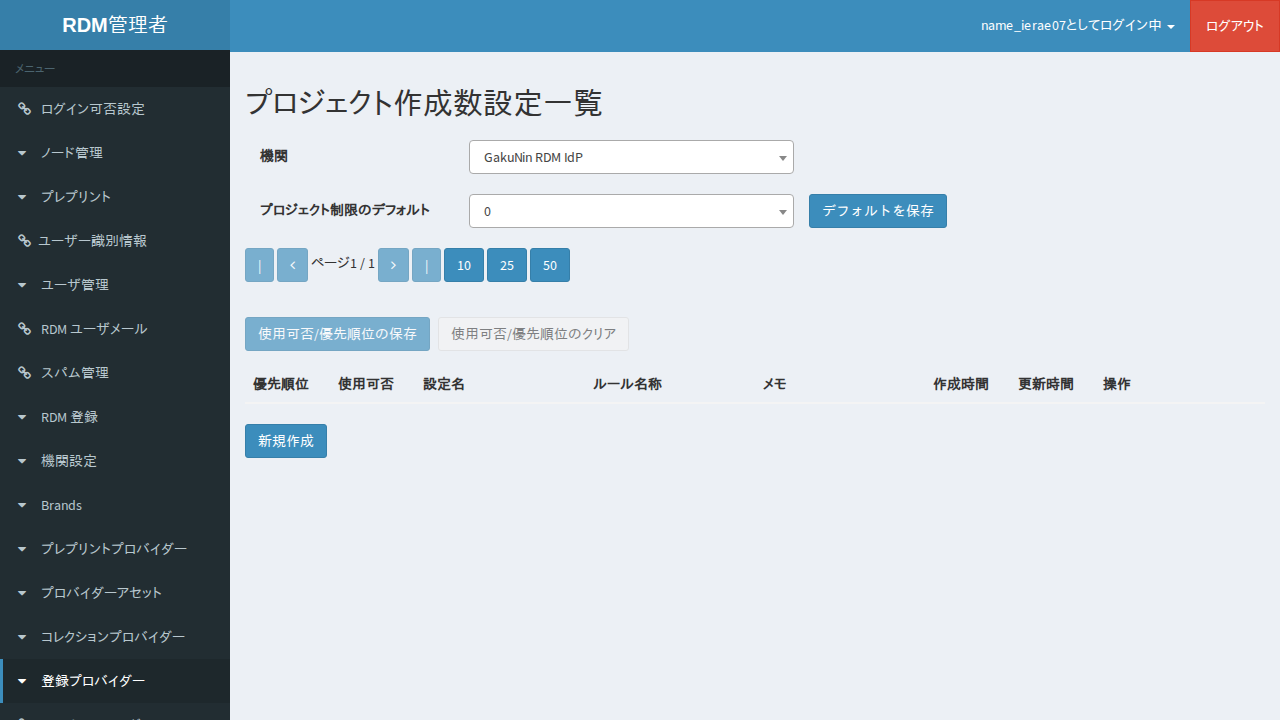

In [ ]:
async def _step(page):
    dropdown = page.locator('#project_limit_number_default_id')

    # 「無制限」「0」「1」... が表示されることを確認
    await expect(dropdown.locator('option[value="-1"]')).to_have_text('無制限', timeout=transition_timeout)
    await expect(dropdown.locator('option[value="0"]')).to_have_text('0', timeout=transition_timeout)
    await expect(dropdown.locator('option[value="1"]')).to_have_text('1', timeout=transition_timeout)
    await expect(dropdown.locator('option[value="10"]')).to_have_text('10', timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクト制限のデフォルト」のドロップダウンリストの中から「0」を選択し、「デフォルトを保存」ボタンを押下する

「プロジェクト制限のデフォルト」が「0」になること


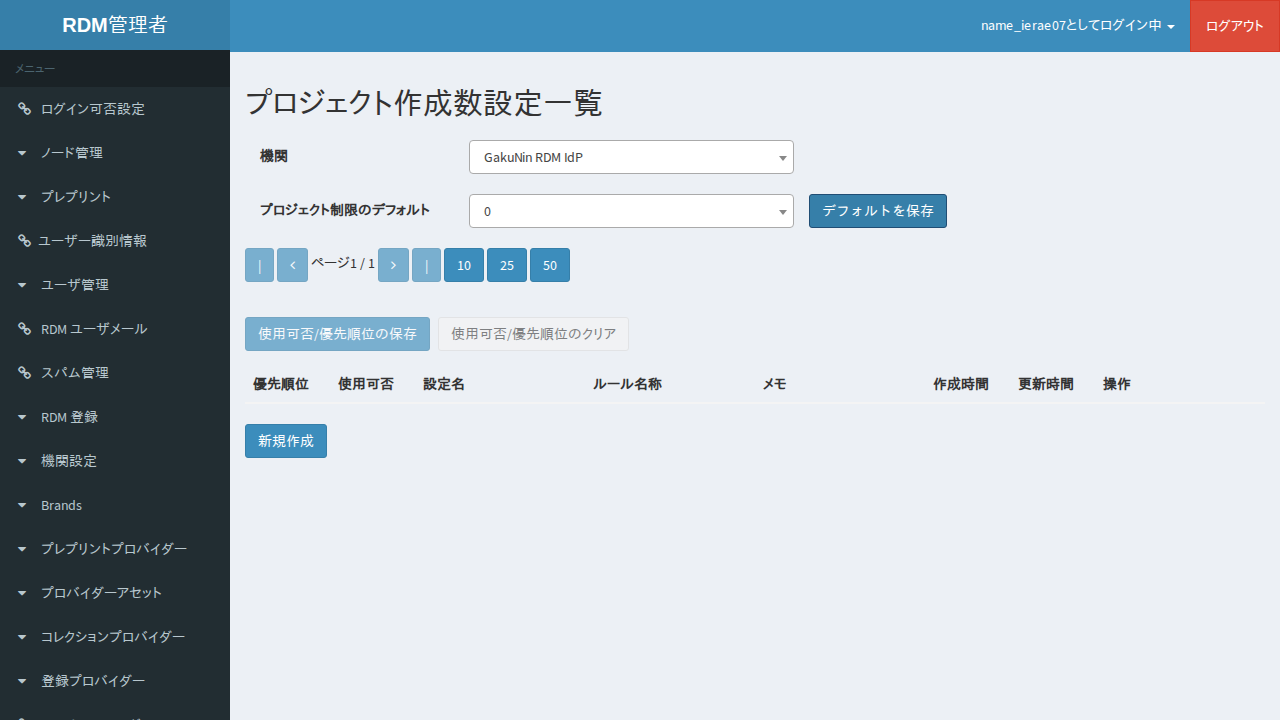

In [12]:
async def _step(page):
    # 「プロジェクト制限のデフォルト」で「0」を選択
    await page.locator('#project_limit_number_default_id').select_option('0')

    # 「デフォルトを保存」ボタンを押下し、保存後の再読み込み完了を待機
    async with page.expect_navigation(wait_until='load', timeout=transition_timeout):
        await page.locator('button', has_text='デフォルトを保存').click()

    # 「プロジェクト制限のデフォルト」が「0」になることを確認
    await expect(page.locator('#project_limit_number_default_id')).to_have_value('0', timeout=transition_timeout)

await run_pw(_step)

## 「新規作成」ボタンを押下する

・「プロジェクト作成数設定(XXXXX)」画面が表示されること   
・XXXXX の箇所には No.10 で選択した機関が表示されていること   


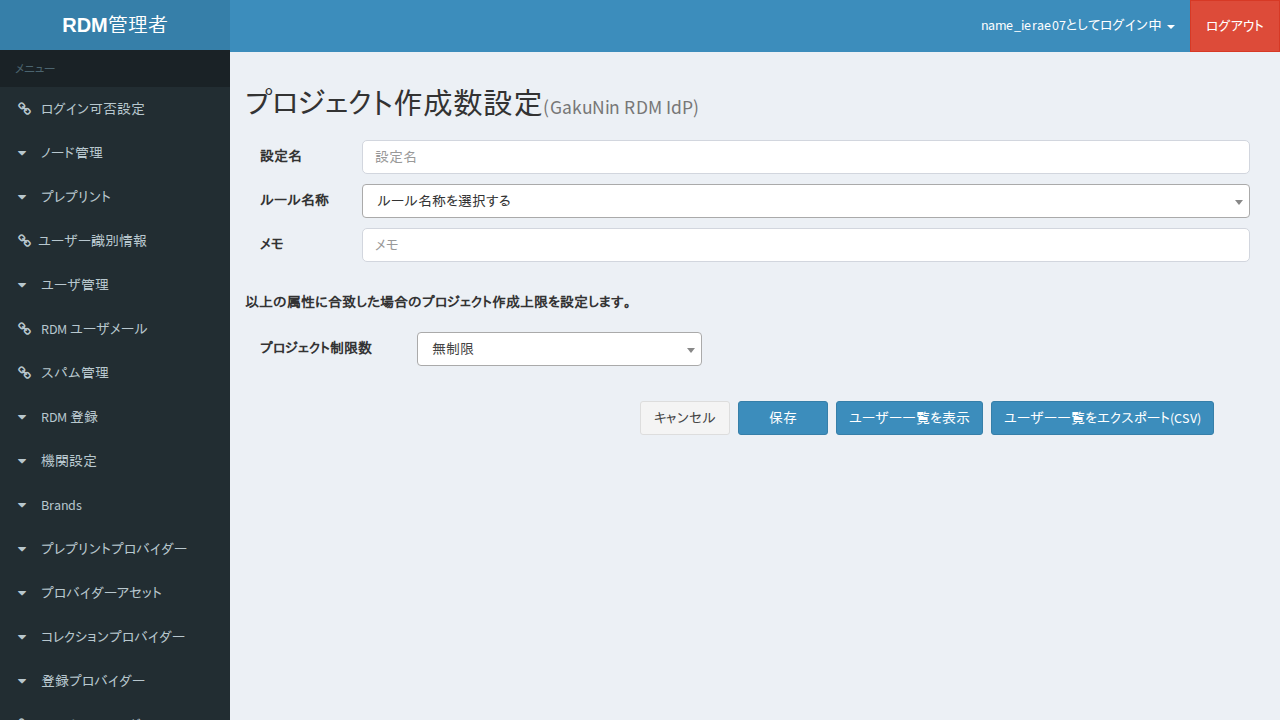

In [ ]:
async def _step(page):
    # 「新規作成」ボタンを押下
    await page.locator('a', has_text='新規作成').click()
    
    # 「プロジェクト作成数設定(XXXXX)」画面が表示されること
    await expect(page.locator('//h2[contains(.,"プロジェクト作成数設定")]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator(f'//h2/small[text()="({institution_name_project_limit_1})"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「設定名」に「setting1」、「ルール名称」のドロップダウンリストの中から「テンプレート作成・変更・削除」シートの No.22 で保存した「template1」、「メモ」に「memo1」を入力する

・「ルール名称」のドロップダウンリストの中に No.38 で「使用可否」を無効にした「template3」が表示されていないこと   
・「テンプレート作成・変更・削除」シートの No.22 で保存した「使用する属性」「値の設定方法」が表示されること   
・「使用する属性」「値の設定方法」「値」の中で「値」のみユーザが入力可能な状態になっていること


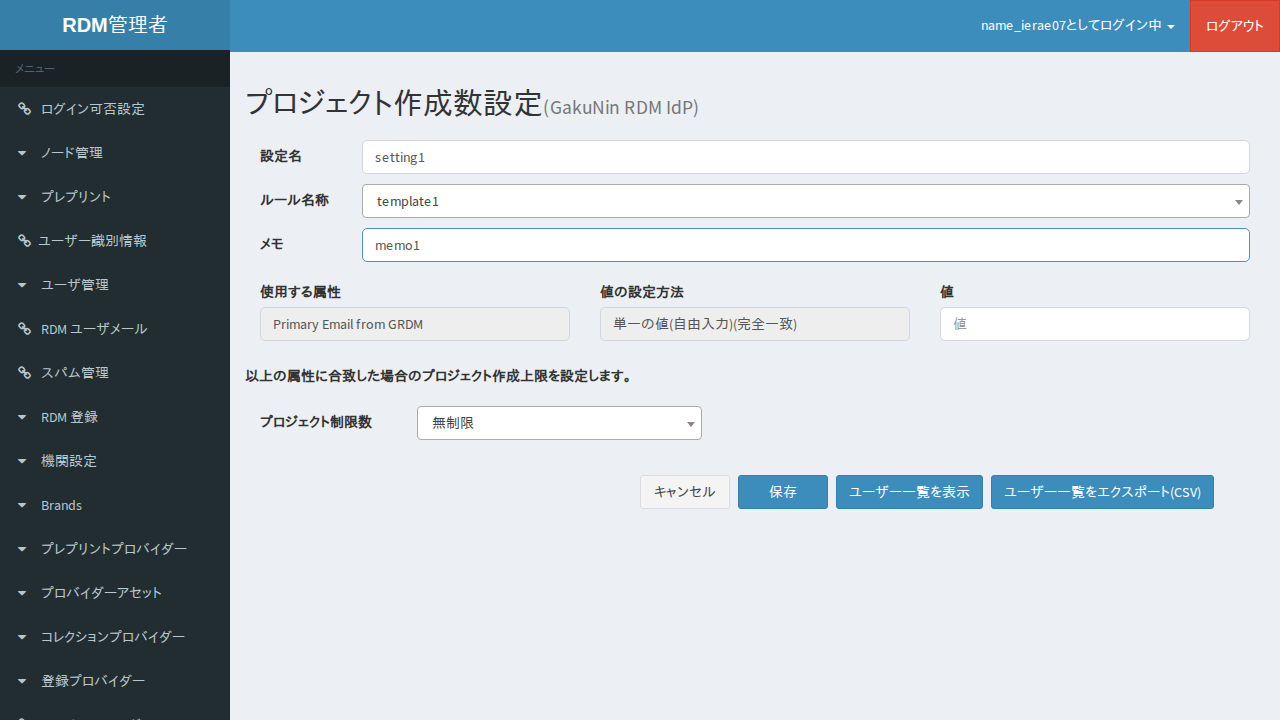

In [14]:
async def _step(page):
    # 「設定名」に「setting1」を入力
    await page.locator('#setting_name_id').fill('setting1')

    # 「ルール名称」で「template1」を選択
    await page.locator('#template_id').select_option(label='template1')

    # 「メモ」に「memo1」を入力
    await page.locator('#memo_id').fill('memo1')
    
    # 「ルール名称」のドロップダウンリストに「template3」が表示されていないことを確認
    await expect(page.locator('#template_id option', has_text='template3')).to_have_count(0, timeout=transition_timeout)

    # 「使用する属性」が表示されることを確認
    await expect(page.locator('//input[@name="attribute_name" and @value="Primary Email from GRDM"]')).to_be_visible(timeout=transition_timeout)

    # 「値の設定方法」が表示されることを確認
    await expect(page.locator('//input[@name="setting_name" and @value="単一の値(自由入力)(完全一致)"]')).to_be_visible(timeout=transition_timeout)

    # 「使用する属性」が入力不可であることを確認
    await expect(page.locator('//input[@name="attribute_name"]')).to_be_disabled(timeout=transition_timeout)

    # 「値の設定方法」が入力不可であることを確認
    await expect(page.locator('//input[@name="setting_name" and @value="単一の値(自由入力)(完全一致)"]')).to_be_disabled(timeout=transition_timeout)

    # 「値」のみ入力可能であることを確認
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_be_editable(timeout=transition_timeout)

await run_pw(_step)

## 「値」に「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」から「@」以降を削除した値、「プロジェクト制限数」のドロップダウンリストの中から「4」を入力する

「値」に「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」の「@」以降を削除した値、「プロジェクト制限数」に「4」が設定されること


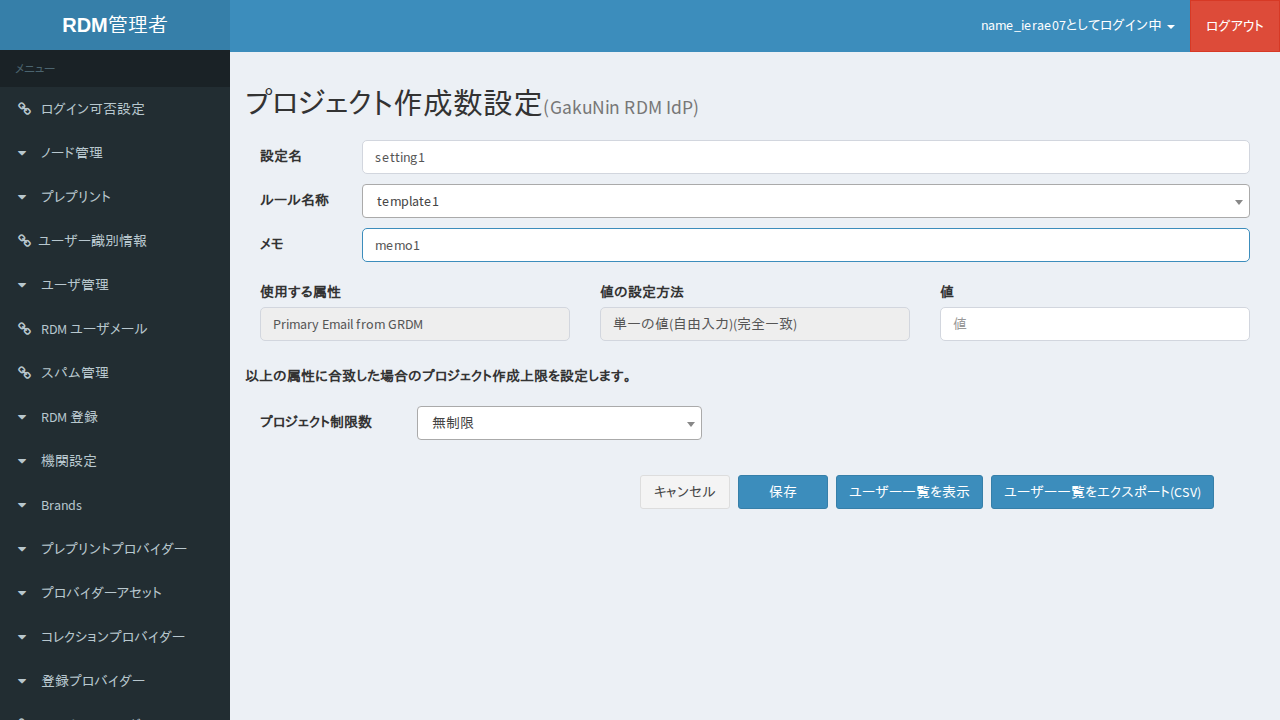

In [ ]:
import os
primary_email = None

async def _step(page):
    global primary_email
    result_dir = default_result_path.split("notebooks/")[0] + "notebooks/"
    template_result_dir = os.path.join(result_dir,'テスト手順-管理者機能-プロジェクト制限数-テンプレート作成・変更・削除')
    primary_email_path = os.path.join(template_result_dir, 'primary_email.txt')

    with open(primary_email_path, 'r') as f:
        primary_email = f.read().strip()

    print(f'Loaded primary_email from: {primary_email_path}')
await run_pw(_step)

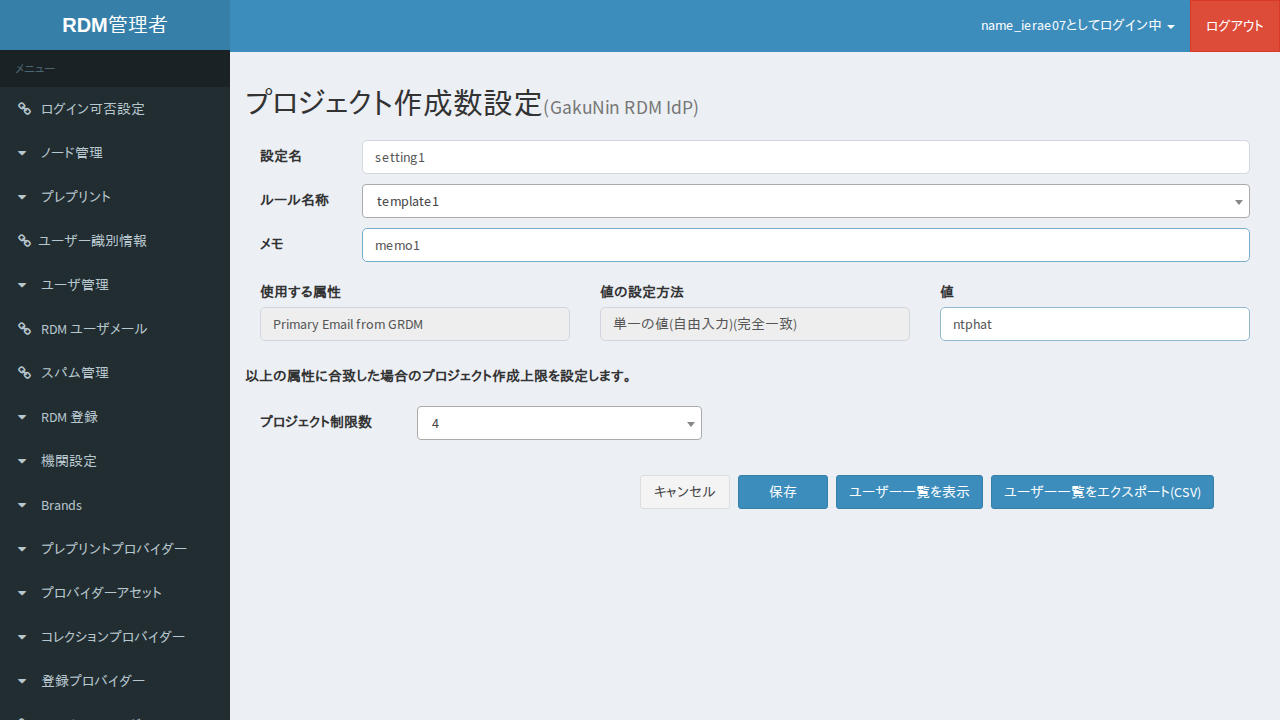

In [16]:
mail_prefix = None
async def _step(page):
    global mail_prefix
    mail_prefix = primary_email.split('@')[0]

    # 「値」にプライマリメールの「@」以前の値を入力
    await page.locator('//input[@name="attribute_value_input"]').fill(mail_prefix)

    # 「プロジェクト制限数」で「4」を選択
    await page.locator('#project_limit_number_id').select_option('4')

    # 「値」が設定されていることを確認
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_have_value(mail_prefix, timeout=transition_timeout)

    # 「プロジェクト制限数」が「4」であることを確認
    await expect(page.locator('#project_limit_number_id')).to_have_value('4', timeout=transition_timeout)

await run_pw(_step)

## 「ユーザー一覧を表示」ボタンを押下する

・「GUID」「ePPN」「ユーザ名」「氏名」「作成済みプロジェクト数」「プロジェクト制限数」が表示されること   
・該当するユーザは居ないため、ユーザーは表示されないこと   


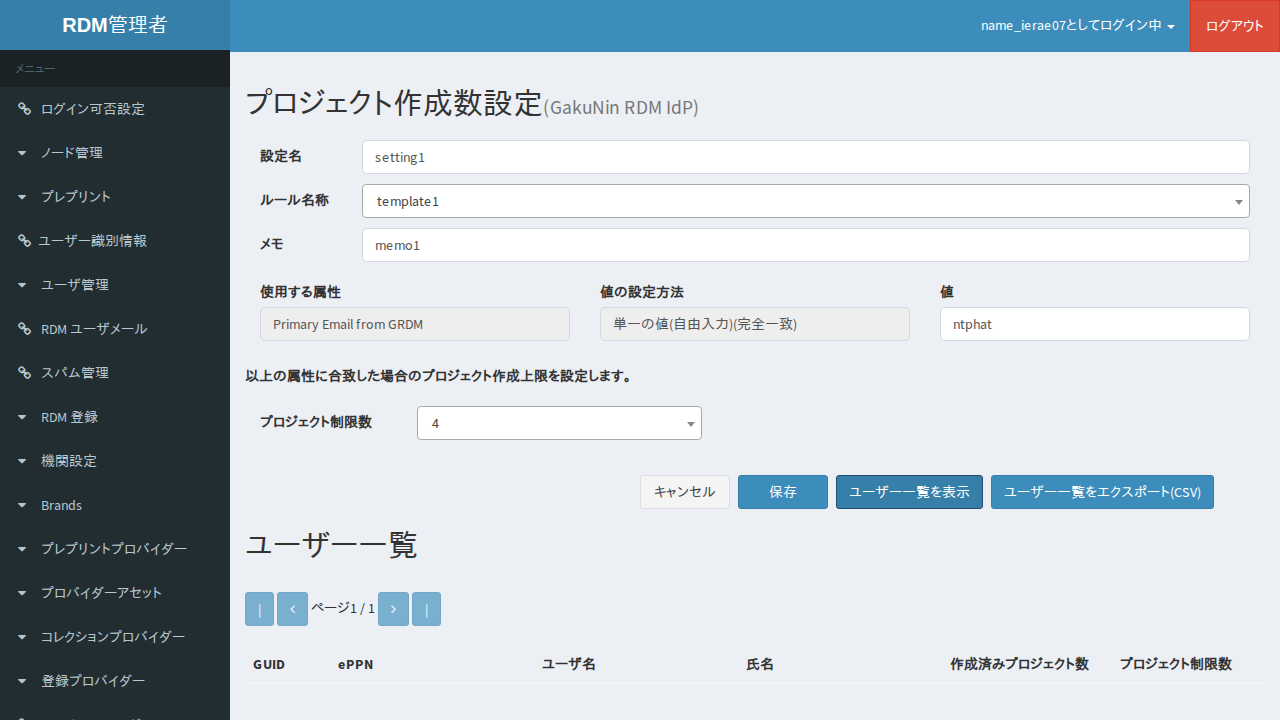

In [17]:
async def _step(page):
    # 「ユーザー一覧を表示」ボタンを押下
    await page.locator('//button[text()="ユーザー一覧を表示"]').click()

    # テーブルヘッダーが表示されることを確認
    await expect(page.locator('//th[normalize-space()="GUID"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="ePPN"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="ユーザ名"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="氏名"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="作成済みプロジェクト数"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="プロジェクト制限数"]')).to_be_visible(timeout=transition_timeout)

    # ユーザーが表示されないことを確認
    await expect(page.locator('#user-table tbody tr')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## 「保存」ボタンを押下する

「プロジェクト作成数設定一覧」画面に No.15 で設定した「設定名」「ルール名称」「メモ」が表示されること


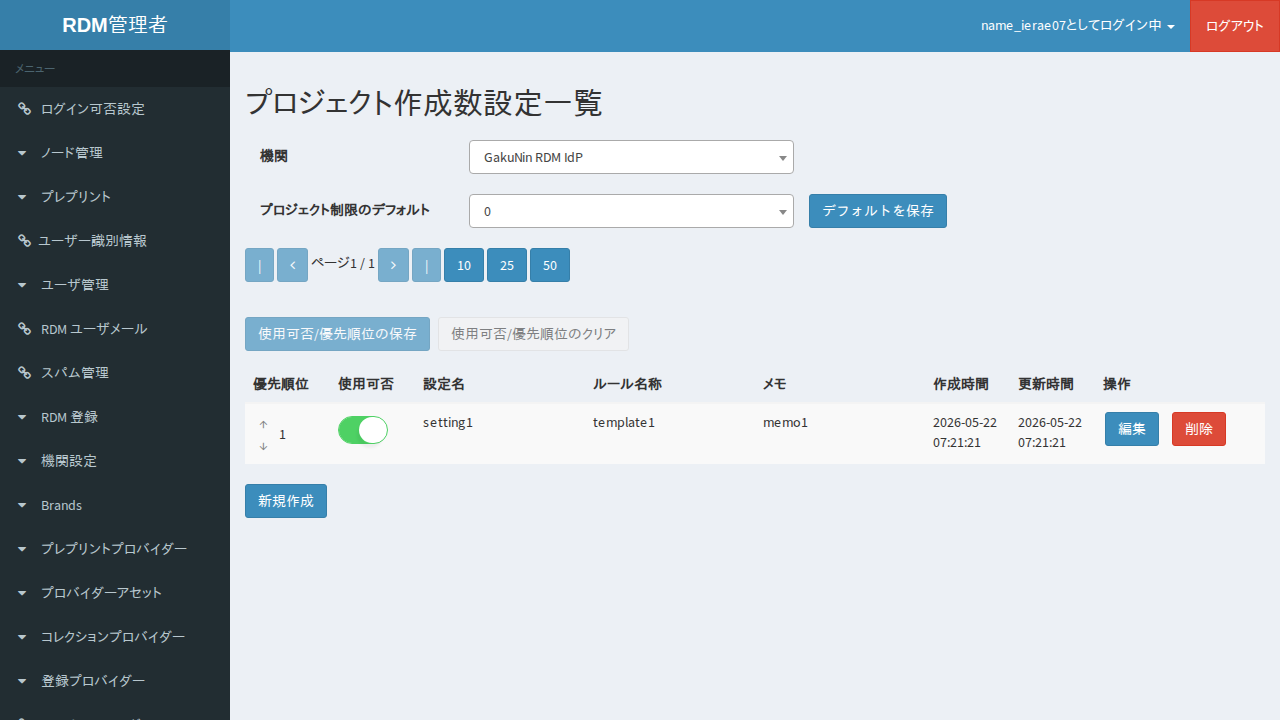

In [18]:
async def _step(page):
    # 「保存」ボタンを押下
    await page.locator('//button[@type="submit" and text()="保存"]').click()

    # 「プロジェクト作成数設定一覧」画面に遷移したことを確認
    await expect( page.locator('//h2[text()="プロジェクト作成数設定一覧"]')).to_be_visible(timeout=transition_timeout)

    # setting1 の行を取得
    row = page.locator('#setting-table tbody tr').filter(has_text='setting1')

    # 「設定名」「ルール名称」「メモ」が表示されることを確認
    await expect(row.locator('td').nth(2)).to_have_text('setting1', timeout=transition_timeout)
    await expect(row.locator('td').nth(3)).to_have_text('template1', timeout=transition_timeout)
    await expect(row.locator('td').nth(4)).to_have_text('memo1', timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクト作成数設定一覧」画面にて No.18 で保存した「setting1」の右端にある「編集」ボタンを押下する

・「プロジェクト作成数設定(XXXXX)」画面に No.18で保存した「設定名」「ルール名称」「メモ」「値」「プロジェクト制限数」が表示されること   
・「ルール名称」の選択は変更できないこと   
・XXXXX の箇所には No.10 で選択した機関が表示されていること   


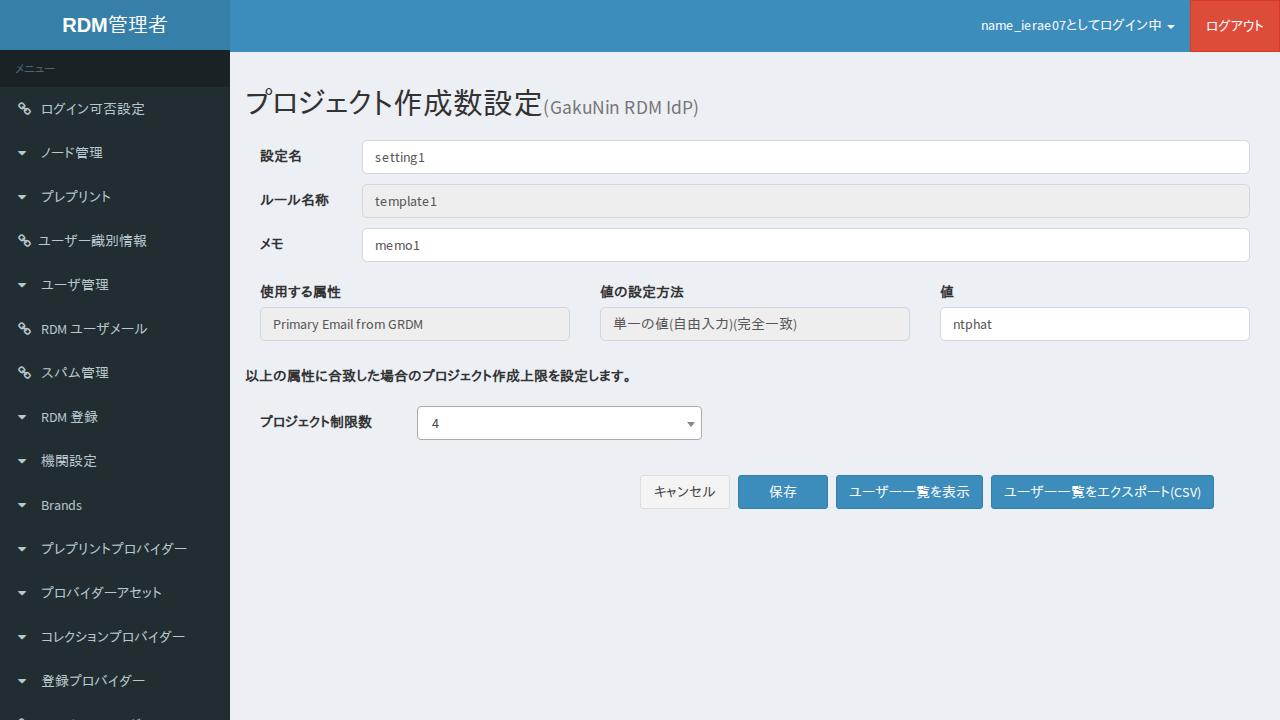

In [ ]:
async def _step(page):
    # setting1 の「編集」ボタンを押下
    row = page.locator('#setting-table tbody tr').filter(has_text='setting1')
    await row.locator('a:text("編集")').click()

    # 「プロジェクト作成数設定(XXXXX)」画面が表示されること
    await expect(page.locator(f'//h2[contains(.,"プロジェクト作成数設定") and contains(.,"{institution_name_project_limit_1}")]')).to_be_visible(timeout=transition_timeout)

    # 「設定名」が表示されること
    await expect(page.locator('#setting_name_id')).to_have_value('setting1', timeout=transition_timeout)

    # 「ルール名称」が表示されること
    await expect(page.locator('#template_id')).to_have_value('template1', timeout=transition_timeout)

    # 「メモ」が表示されること
    await expect(page.locator('#memo_id')).to_have_value('memo1', timeout=transition_timeout)

    # 「値」が表示されること
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_have_value(mail_prefix, timeout=transition_timeout)

    # 「プロジェクト制限数」が表示されること
    await expect(page.locator('#project_limit_number_id')).to_have_value('4', timeout=transition_timeout)

    # 「ルール名称」が変更できないこと
    await expect(page.locator('#template_id')).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「ユーザー一覧を表示」ボタンを押下する

・「GUID」「ePPN」「ユーザ名」「氏名」「作成済みプロジェクト数」「プロジェクト制限数」が表示されること
・該当するユーザは居ないため、ユーザーは表示されないこと


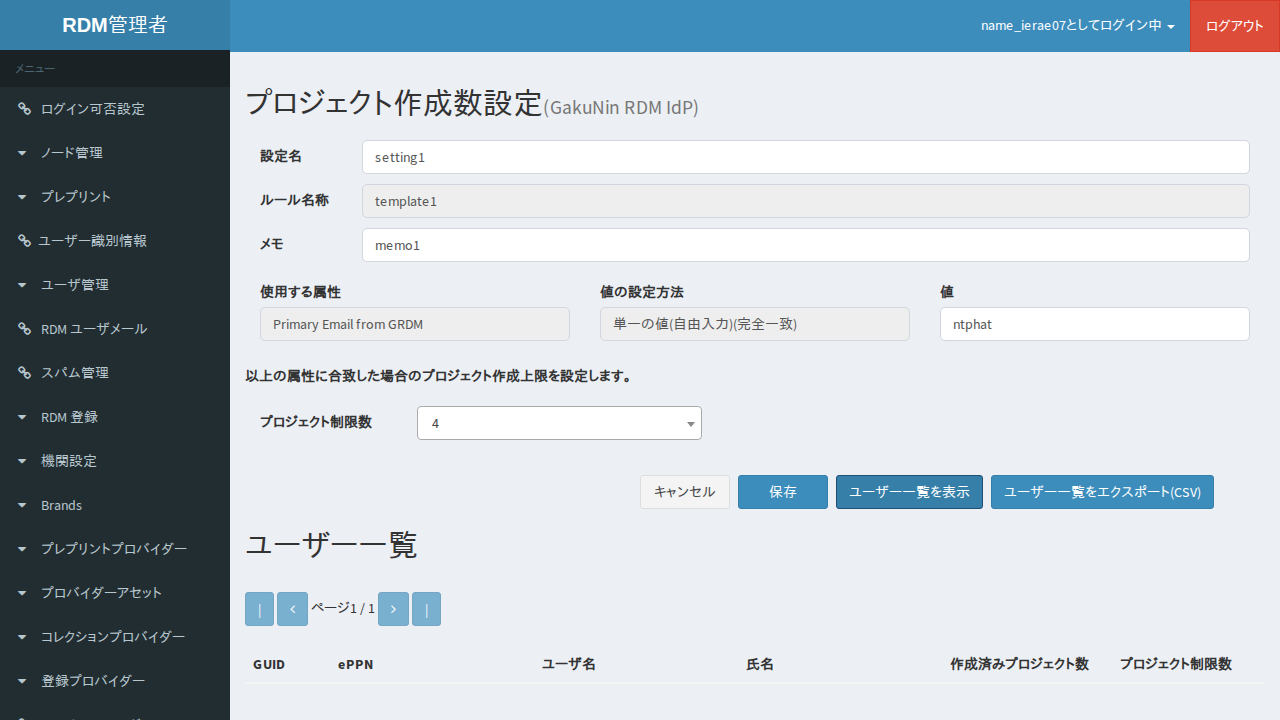

In [20]:
async def _step(page):
    # 「ユーザー一覧を表示」ボタンを押下
    await page.locator('//button[text()="ユーザー一覧を表示"]').click()

    # テーブルヘッダーが表示されることを確認
    await expect(page.locator('//th[normalize-space()="GUID"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="ePPN"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="ユーザ名"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="氏名"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="作成済みプロジェクト数"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="プロジェクト制限数"]')).to_be_visible(timeout=transition_timeout)

    # ユーザーが表示されないことを確認
    await expect(page.locator('#user-table tbody tr')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## 「値」を「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」に変更する

「値」に「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」が設定されること


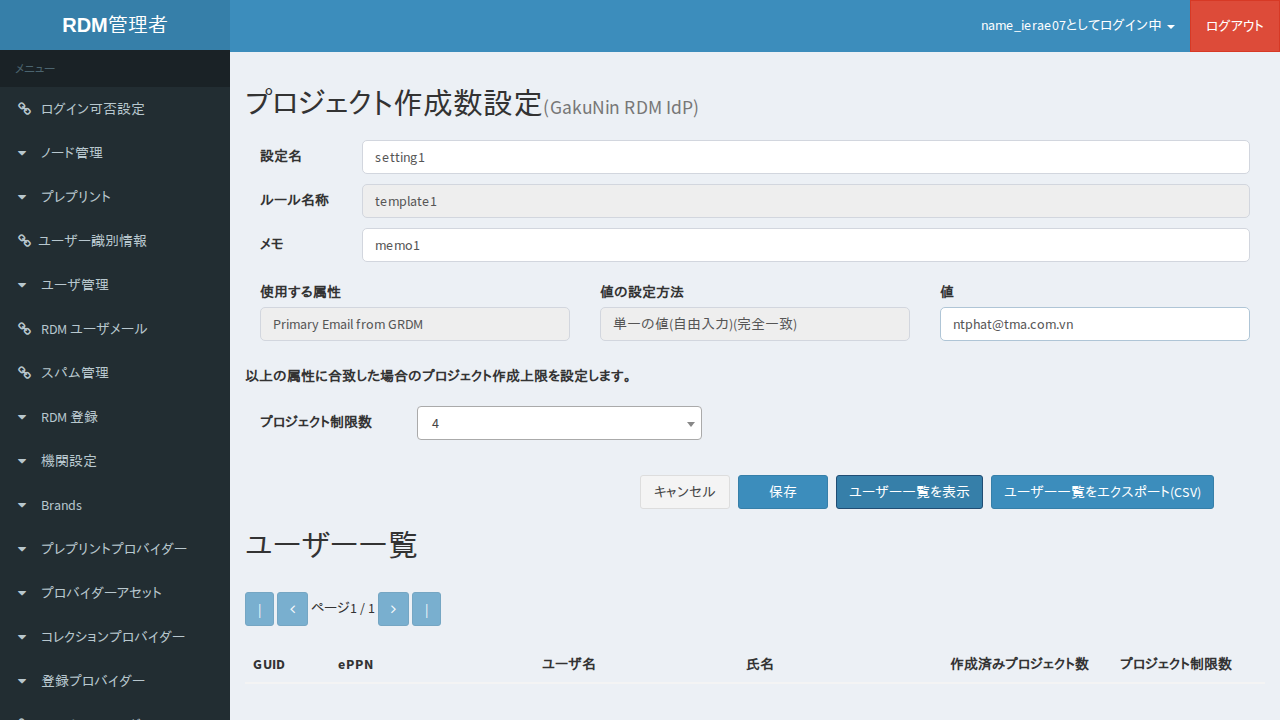

In [21]:
async def _step(page):
    # 「値」をプライマリメールに変更
    await page.locator('//input[@name="attribute_value_input"]').fill(primary_email)

    # 「値」に設定されることを確認
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_have_value(primary_email, timeout=transition_timeout)

await run_pw(_step)

## 「ユーザー一覧を表示」ボタンを押下する

・「GUID」「ePPN」「ユーザ名」「氏名」「作成済みプロジェクト数」「プロジェクト制限数」が表示されること   
・「テンプレート作成・変更・削除」シートの No.4 のユーザーが表示されること   


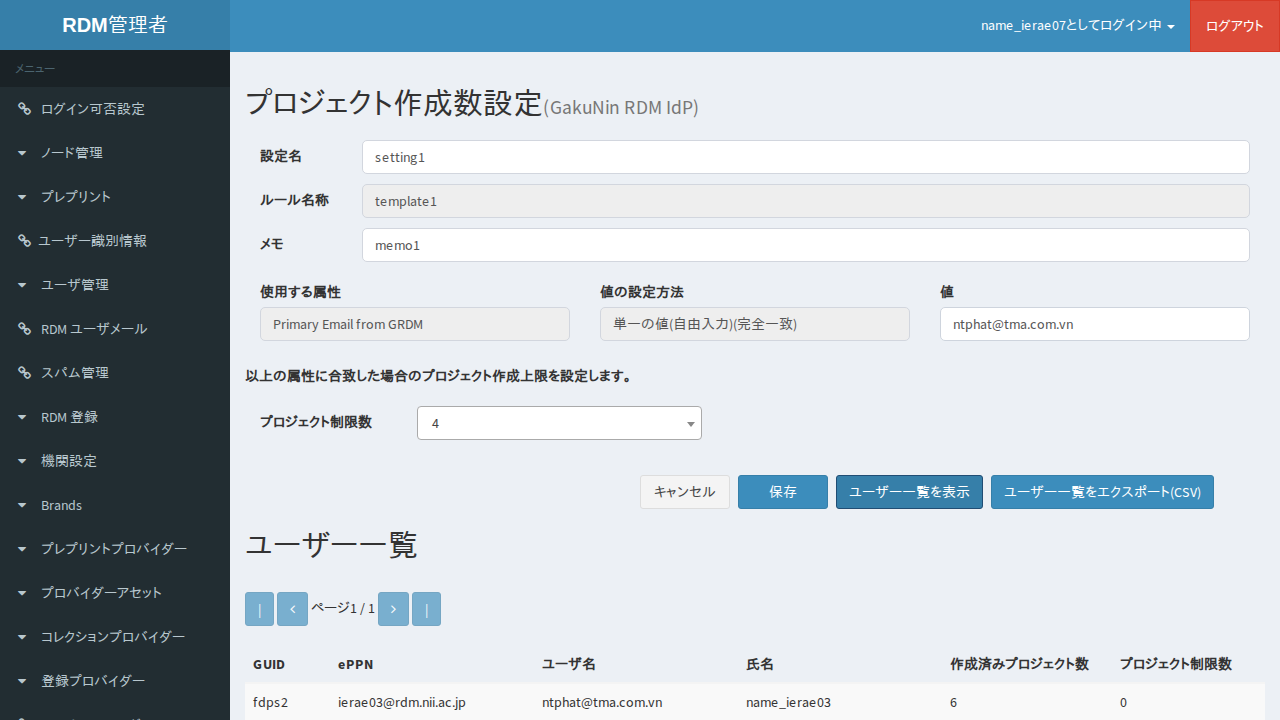

In [22]:
async def _step(page):
    # 「ユーザー一覧を表示」ボタンを押下
    await page.locator('//button[text()="ユーザー一覧を表示"]').click()

    # テーブルヘッダーが表示されることを確認
    await expect(page.locator('//th[normalize-space()="GUID"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="ePPN"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="ユーザ名"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="氏名"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="作成済みプロジェクト数"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//th[normalize-space()="プロジェクト制限数"]')).to_be_visible(timeout=transition_timeout)

    # No.4 のユーザーが表示されることを確認
    user_row = page.locator('#user-table tbody tr').filter(has_text=primary_email)
    await expect(user_row).to_be_visible(timeout = transition_timeout)

await run_pw(_step)

## 「保存」ボタンを押下する

「プロジェクト作成数設定一覧」画面に No.15 で設定した「設定名」「ルール名称」「メモ」が表示されること


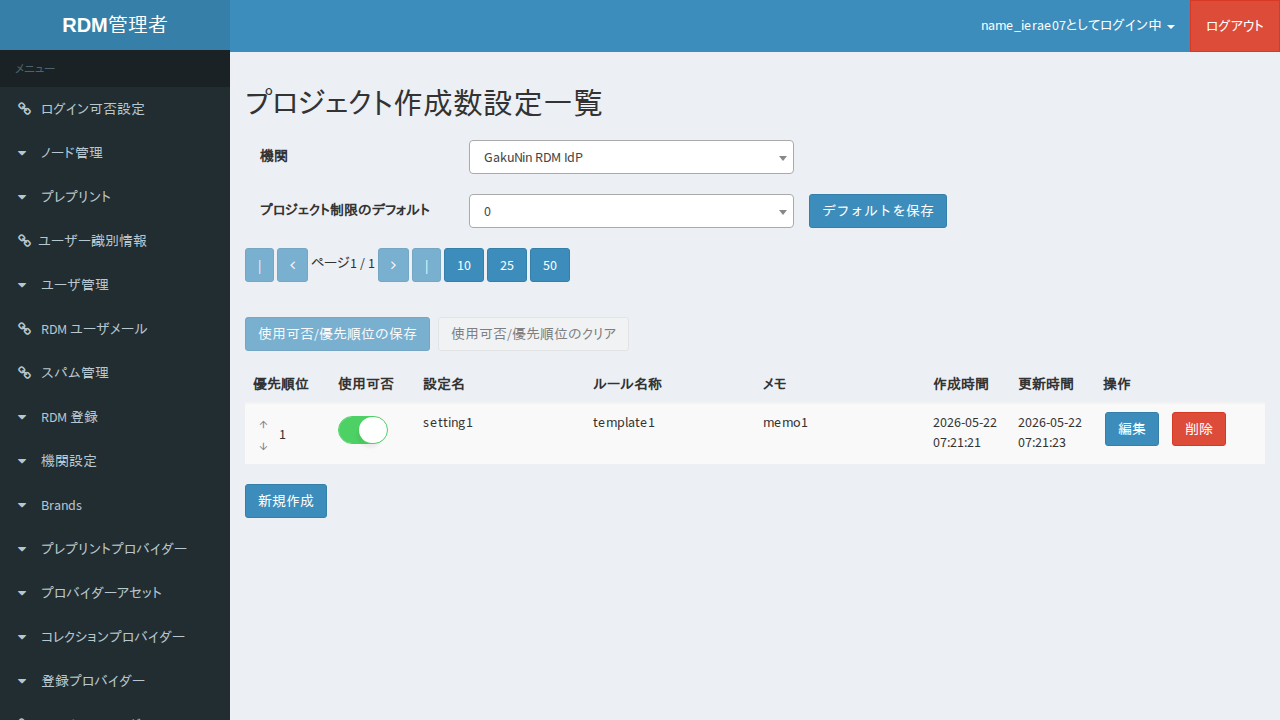

In [23]:
async def _step(page):
    # 「保存」ボタンを押下
    await page.locator('//button[@type="submit" and text()="保存"]').click()

    # 「プロジェクト作成数設定一覧」画面に遷移したことを確認
    await expect( page.locator('//h2[text()="プロジェクト作成数設定一覧"]')).to_be_visible(timeout=transition_timeout)

    # setting1 の行を取得
    row = page.locator('#setting-table tbody tr').filter(has_text='setting1')

    # 「設定名」「ルール名称」「メモ」が表示されることを確認
    await expect(row.locator('td').nth(2)).to_have_text('setting1', timeout=transition_timeout)
    await expect(row.locator('td').nth(3)).to_have_text('template1', timeout=transition_timeout)
    await expect(row.locator('td').nth(4)).to_have_text('memo1', timeout=transition_timeout)

await run_pw(_step)

## 「新規作成」ボタンを押下する

・「プロジェクト作成数設定(XXXXX)」画面が表示されること   
・XXXXX の箇所には No.10 で選択した機関が表示されていること   


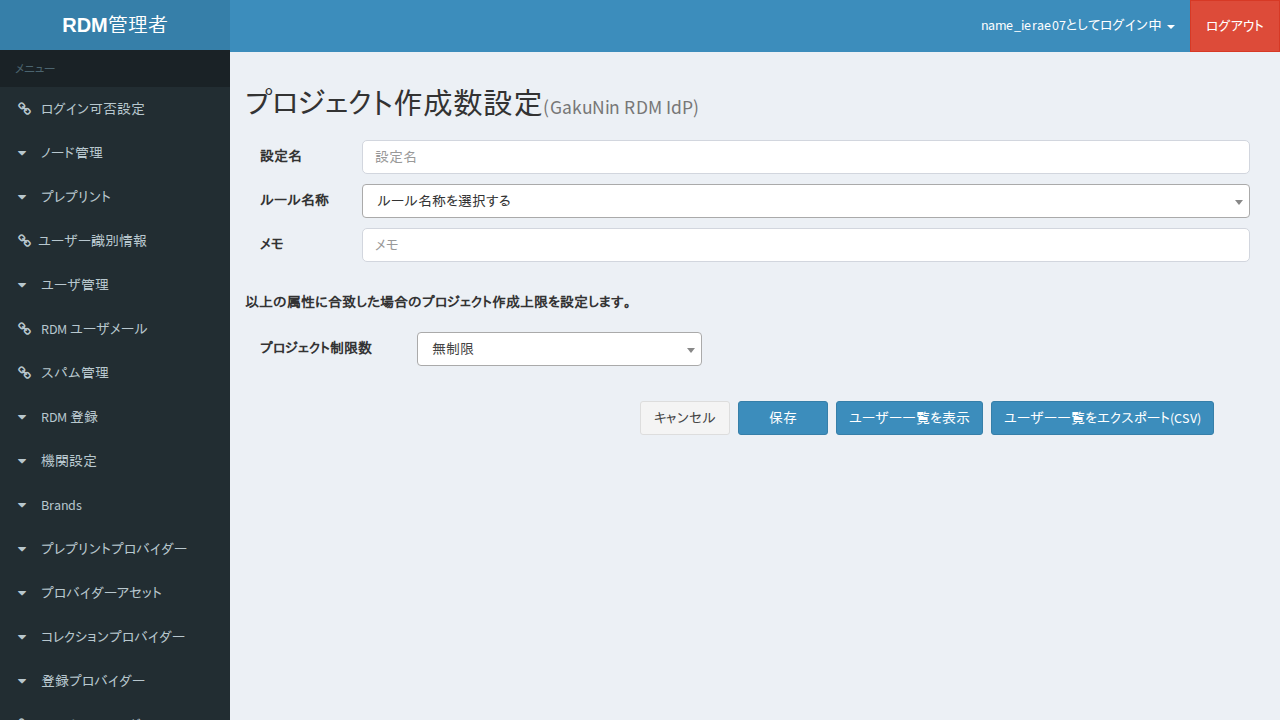

In [ ]:
async def _step(page):
    # 「新規作成」ボタンを押下
    await page.locator('a', has_text='新規作成').click()
    
    # 「プロジェクト作成数設定(XXXXX)」画面が表示されること
    await expect(page.locator('//h2[contains(.,"プロジェクト作成数設定")]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator(f'//h2/small[text()="({institution_name_project_limit_1})"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「設定名」に「setting2」、「ルール名称」のドロップダウンリストの中から「テンプレート作成・変更・削除」シートの No.22 で保存した「template1」、「メモ」に「memo2」を入力する

・「ルール名称」のドロップダウンリストの中に No.38 で「使用可否」を無効にした「template3」が表示されていないこと   
・「テンプレート作成・変更・削除」シートの No.22 で保存した「使用する属性」「値の設定方法」が表示されること   
・「使用する属性」「値の設定方法」「値」の中で「値」のみユーザが入力可能な状態になっていること   


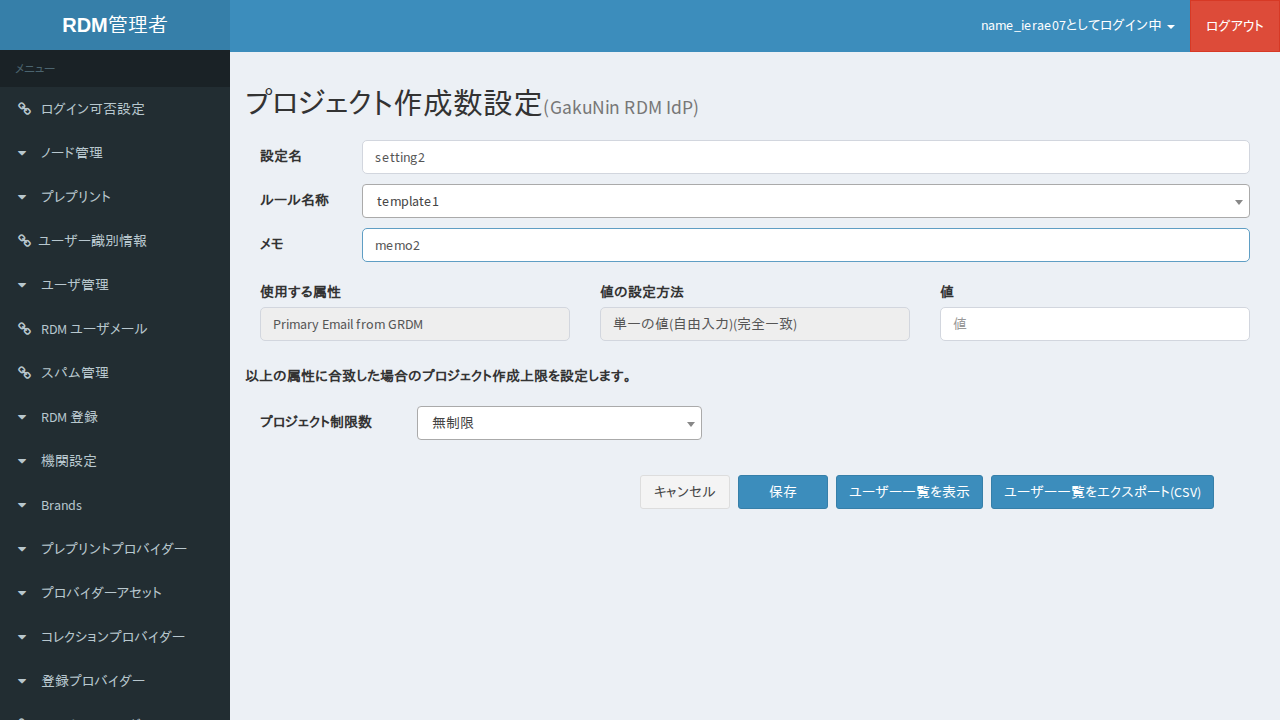

In [27]:
async def _step(page):
    # 「設定名」に「setting2」を入力
    await page.locator('#setting_name_id').fill('setting2')

    # 「ルール名称」で「template1」を選択
    await page.locator('#template_id').select_option(label='template1')

    # 「メモ」に「memo1」を入力
    await page.locator('#memo_id').fill('memo2')
    
    # 「ルール名称」のドロップダウンリストに「template3」が表示されていないことを確認
    await expect(page.locator('#template_id option', has_text='template3')).to_have_count(0, timeout=transition_timeout)

    # 「使用する属性」が表示されることを確認
    await expect(page.locator('//input[@name="attribute_name" and @value="Primary Email from GRDM"]')).to_be_visible(timeout=transition_timeout)

    # 「値の設定方法」が表示されることを確認
    await expect(page.locator('//input[@name="setting_name" and @value="単一の値(自由入力)(完全一致)"]')).to_be_visible(timeout=transition_timeout)

    # 「使用する属性」が入力不可であることを確認
    await expect(page.locator('//input[@name="attribute_name"]')).to_be_disabled(timeout=transition_timeout)

    # 「値の設定方法」が入力不可であることを確認
    await expect(page.locator('//input[@name="setting_name" and @value="単一の値(自由入力)(完全一致)"]')).to_be_disabled(timeout=transition_timeout)

    # 「値」のみ入力可能であることを確認
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_be_editable(timeout=transition_timeout)

await run_pw(_step)

## 「値」に「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」、「プロジェクト制限数」のドロップダウンリストの中から「3」を入力する

「値」に「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」、「プロジェクト制限数」に「3」が設定されること


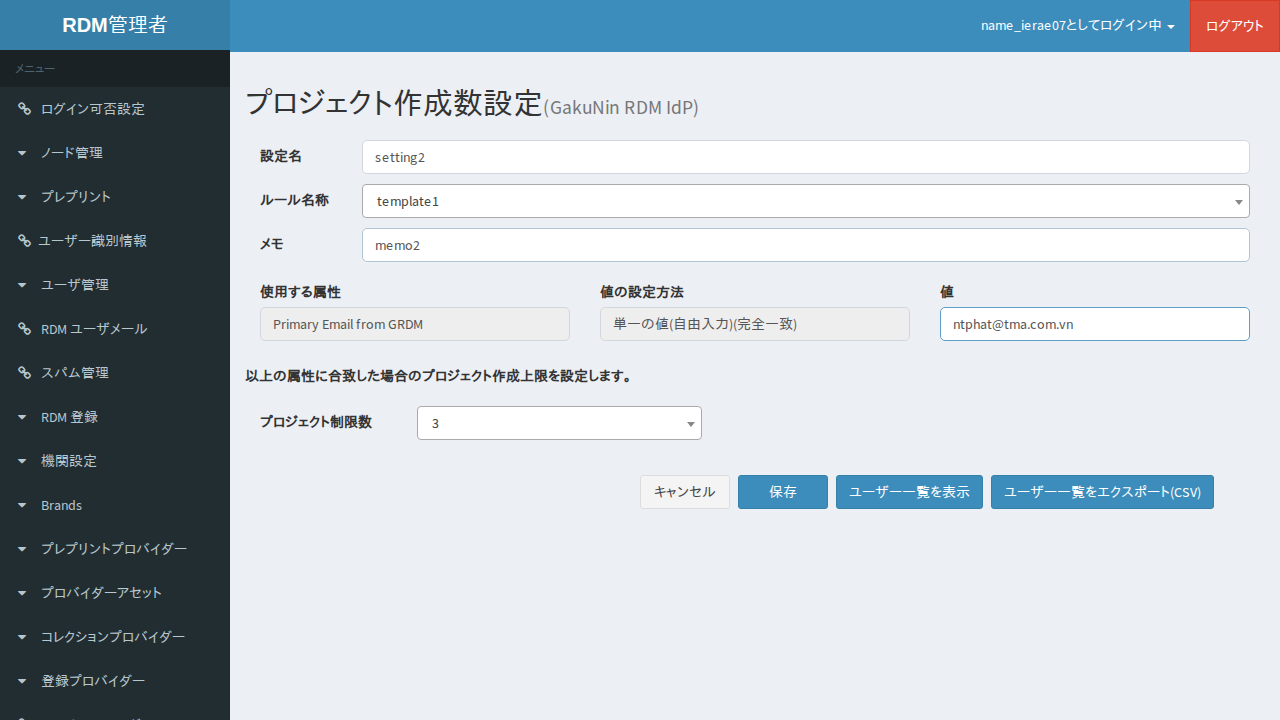

In [28]:
async def _step(page):
    # 「値」にプライマリメールを入力
    await page.locator('//input[@name="attribute_value_input"]').fill(primary_email)

    # 「プロジェクト制限数」で「3」を選択
    await page.locator('#project_limit_number_id').select_option('3')

    # 「値」が設定されていることを確認
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_have_value(primary_email, timeout=transition_timeout)

    # 「プロジェクト制限数」が「3」であることを確認
    await expect(page.locator('#project_limit_number_id')).to_have_value('3', timeout=transition_timeout)

await run_pw(_step)

## 「保存」ボタンを押下する

「プロジェクト作成数設定一覧」画面に No.27 で設定した「設定名」「ルール名称」「メモ」が表示されること


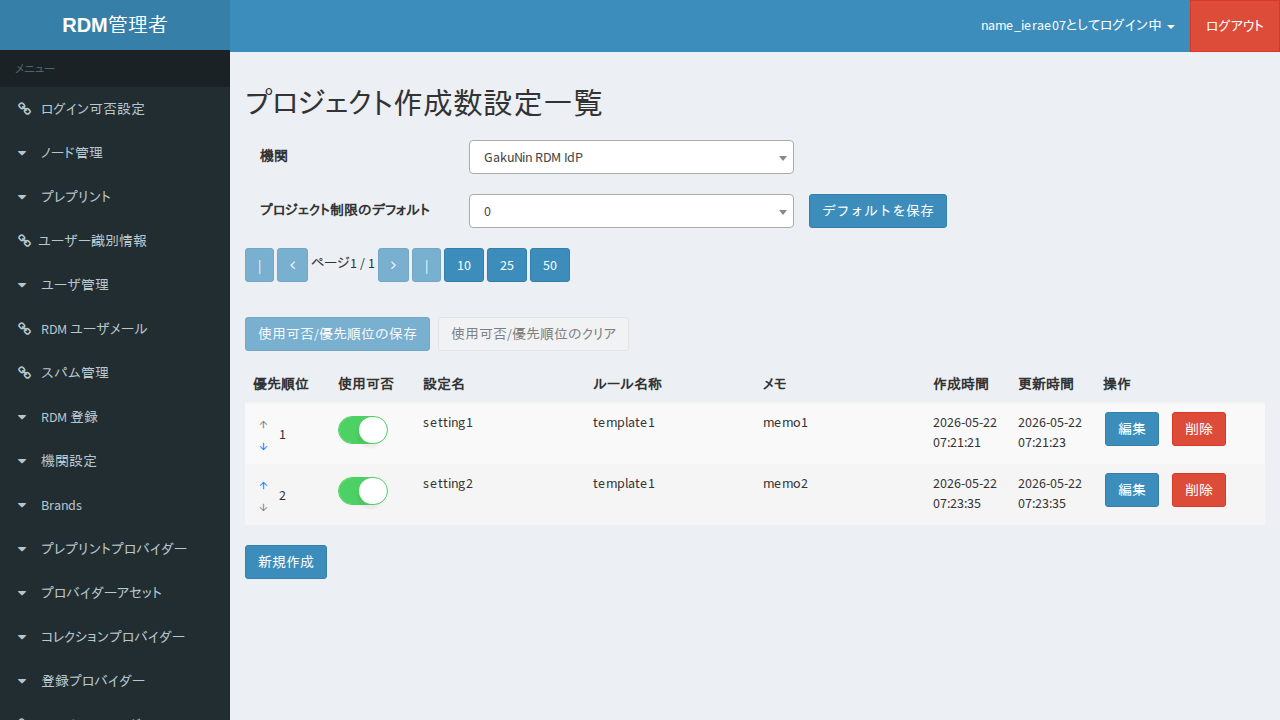

In [29]:
async def _step(page):
    # 「保存」ボタンを押下
    await page.locator('//button[@type="submit" and text()="保存"]').click()

    # 「プロジェクト作成数設定一覧」画面に遷移したことを確認
    await expect( page.locator('//h2[text()="プロジェクト作成数設定一覧"]')).to_be_visible(timeout=transition_timeout)

    # setting2 の行を取得
    row = page.locator('#setting-table tbody tr').filter(has_text='setting2')

    # 「設定名」「ルール名称」「メモ」が表示されることを確認
    await expect(row.locator('td').nth(2)).to_have_text('setting2', timeout=transition_timeout)
    await expect(row.locator('td').nth(3)).to_have_text('template1', timeout=transition_timeout)
    await expect(row.locator('td').nth(4)).to_have_text('memo2', timeout=transition_timeout)

await run_pw(_step)

## 「新規作成」ボタンを押下する

・「プロジェクト作成数設定(XXXXX)」画面が表示されること   
・XXXXX の箇所には No.10 で選択した機関が表示されていること   


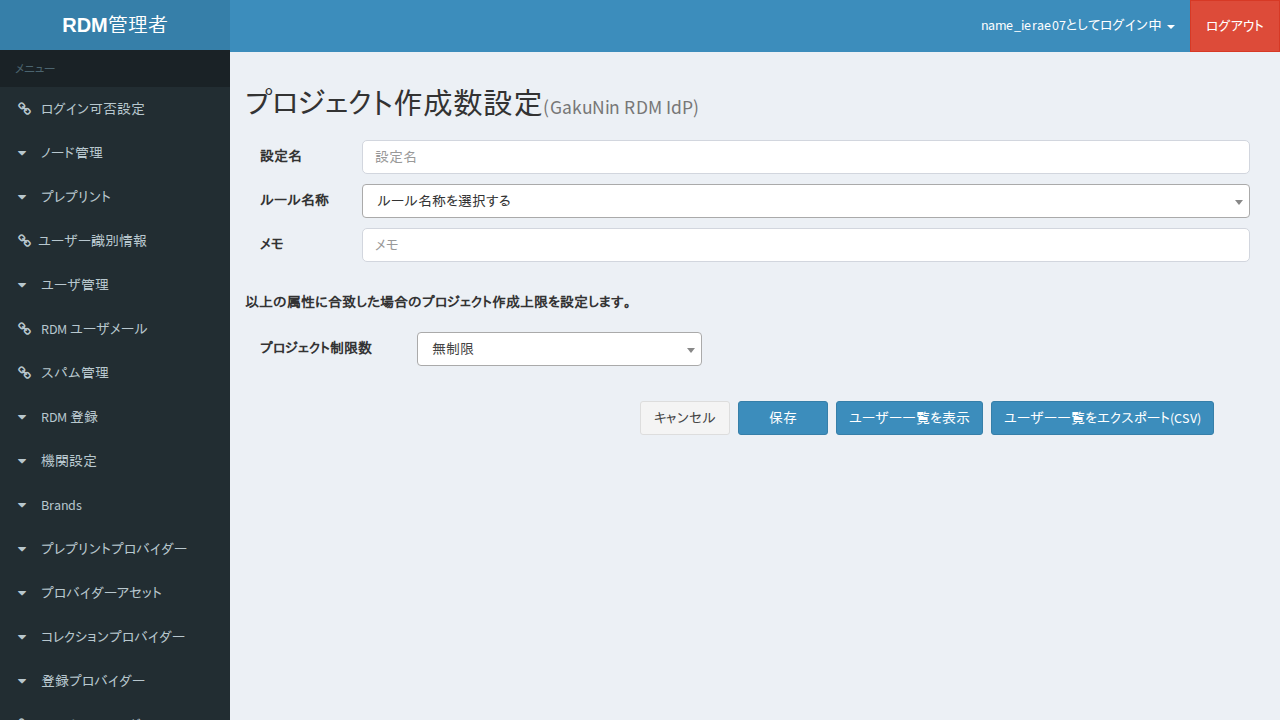

In [ ]:
async def _step(page):
    # 「新規作成」ボタンを押下
    await page.locator('a', has_text='新規作成').click()
    
    # 「プロジェクト作成数設定(XXXXX)」画面が表示されること
    await expect(page.locator('//h2[contains(.,"プロジェクト作成数設定")]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator(f'//h2/small[text()="({institution_name_project_limit_1})"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「設定名」に「setting3」、「ルール名称」のドロップダウンリストの中から「テンプレート作成・変更・削除」シートの No.22 で保存した「template1」、「メモ」に「memo3」を入力する

・「ルール名称」のドロップダウンリストの中に No.38 で「使用可否」を無効にした「template3」が表示されていないこと   
・「テンプレート作成・変更・削除」シートの No.22 で保存した「使用する属性」「値の設定方法」が表示されること   
・「使用する属性」「値の設定方法」「値」の中で「値」のみユーザが入力可能な状態になっていること   


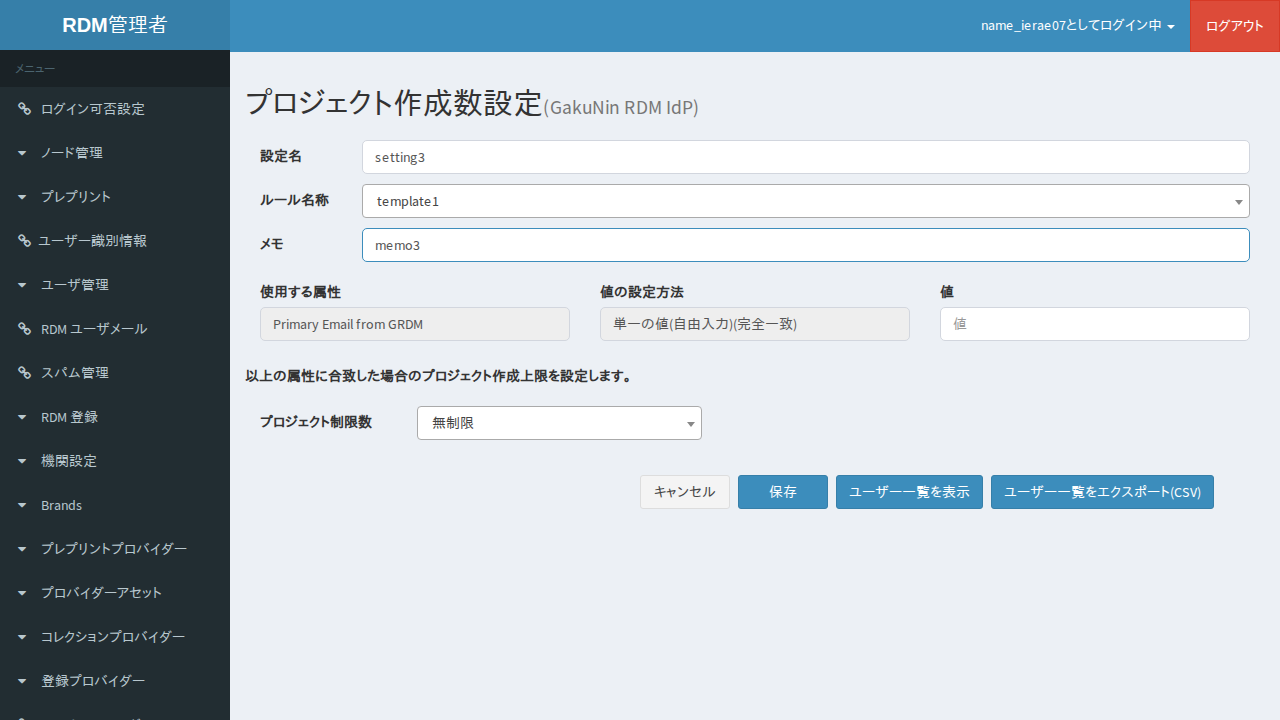

In [31]:
async def _step(page):
    # 「設定名」に「setting3」を入力
    await page.locator('#setting_name_id').fill('setting3')

    # 「ルール名称」で「template1」を選択
    await page.locator('#template_id').select_option(label='template1')

    # 「メモ」に「memo3」を入力
    await page.locator('#memo_id').fill('memo3')
    
    # 「ルール名称」のドロップダウンリストに「template3」が表示されていないことを確認
    await expect(page.locator('#template_id option', has_text='template3')).to_have_count(0, timeout=transition_timeout)

    # 「使用する属性」が表示されることを確認
    await expect(page.locator('//input[@name="attribute_name" and @value="Primary Email from GRDM"]')).to_be_visible(timeout=transition_timeout)

    # 「値の設定方法」が表示されることを確認
    await expect(page.locator('//input[@name="setting_name" and @value="単一の値(自由入力)(完全一致)"]')).to_be_visible(timeout=transition_timeout)

    # 「使用する属性」が入力不可であることを確認
    await expect(page.locator('//input[@name="attribute_name"]')).to_be_disabled(timeout=transition_timeout)

    # 「値の設定方法」が入力不可であることを確認
    await expect(page.locator('//input[@name="setting_name" and @value="単一の値(自由入力)(完全一致)"]')).to_be_disabled(timeout=transition_timeout)

    # 「値」のみ入力可能であることを確認
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_be_editable(timeout=transition_timeout)

await run_pw(_step)

## 「値」に「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」、「プロジェクト制限数」のドロップダウンリストの中から「2」を入力する

「値」に「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」、「プロジェクト制限数」に「2」が設定されること


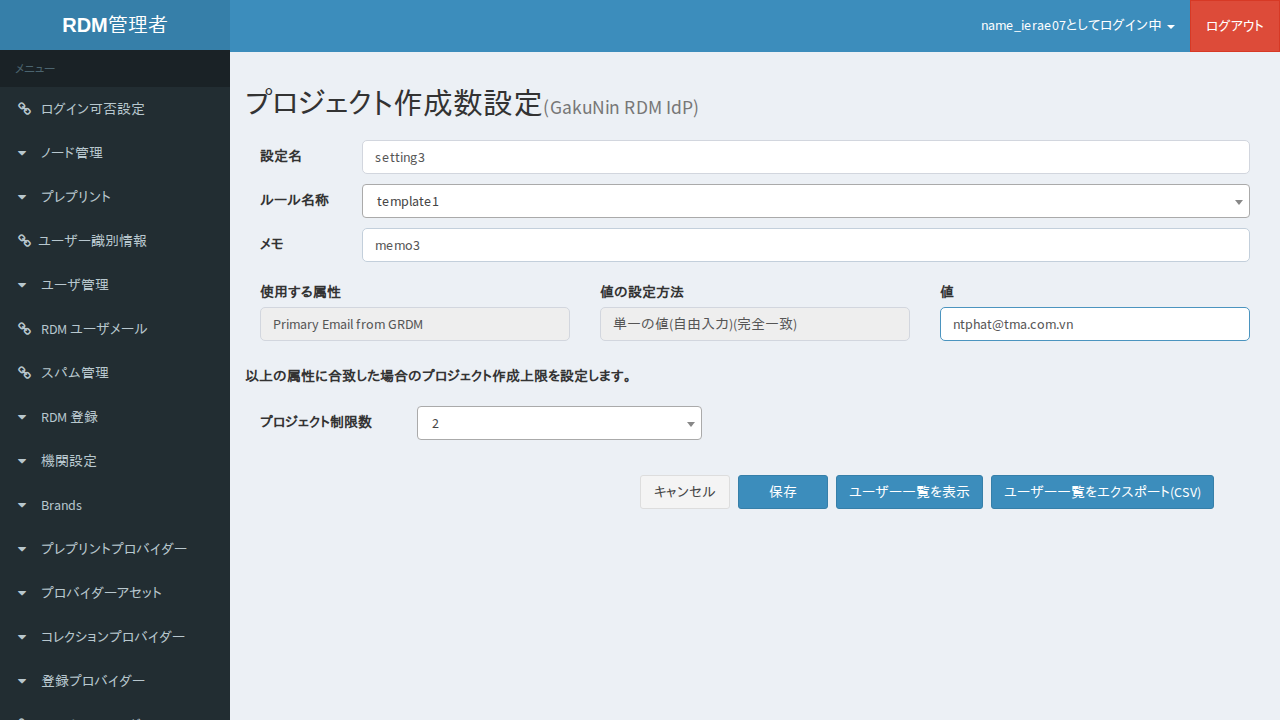

In [32]:
async def _step(page):
    # 「値」にプライマリメールを入力
    await page.locator('//input[@name="attribute_value_input"]').fill(primary_email)

    # 「プロジェクト制限数」で「2」を選択
    await page.locator('#project_limit_number_id').select_option('2')

    # 「値」が設定されていることを確認
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_have_value(primary_email, timeout=transition_timeout)

    # 「プロジェクト制限数」が「2」であることを確認
    await expect(page.locator('#project_limit_number_id')).to_have_value('2', timeout=transition_timeout)

await run_pw(_step)

## 「保存」ボタンを押下する

「プロジェクト作成数設定一覧」画面に No.32 で設定した「設定名」「ルール名称」「メモ」が表示されること


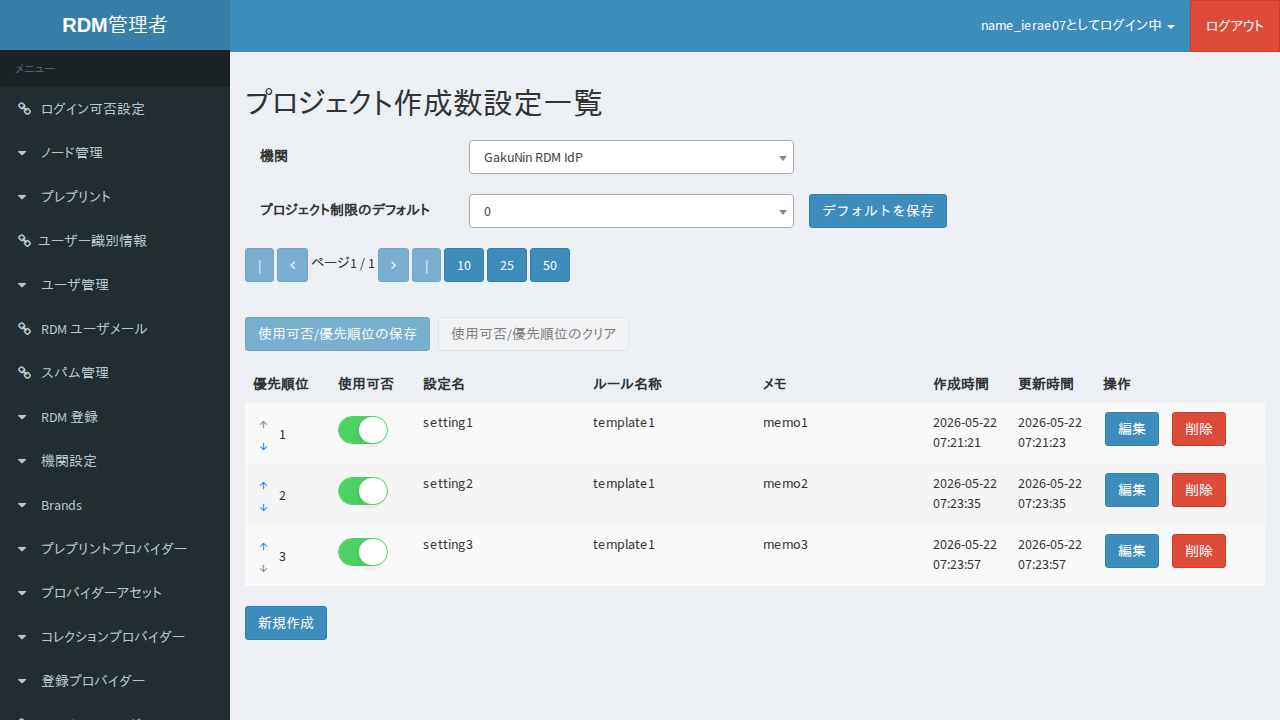

In [33]:
async def _step(page):
    # 「保存」ボタンを押下
    await page.locator('//button[@type="submit" and text()="保存"]').click()

    # 「プロジェクト作成数設定一覧」画面に遷移したことを確認
    await expect( page.locator('//h2[text()="プロジェクト作成数設定一覧"]')).to_be_visible(timeout=transition_timeout)

    # setting3 の行を取得
    row = page.locator('#setting-table tbody tr').filter(has_text='setting3')

    # 「設定名」「ルール名称」「メモ」が表示されることを確認
    await expect(row.locator('td').nth(2)).to_have_text('setting3', timeout=transition_timeout)
    await expect(row.locator('td').nth(3)).to_have_text('template1', timeout=transition_timeout)
    await expect(row.locator('td').nth(4)).to_have_text('memo3', timeout=transition_timeout)

await run_pw(_step)

## 「新規作成」ボタンを押下する

・「プロジェクト作成数設定(XXXXX)」画面が表示されること   
・XXXXX の箇所には No.10 で選択した機関が表示されていること   


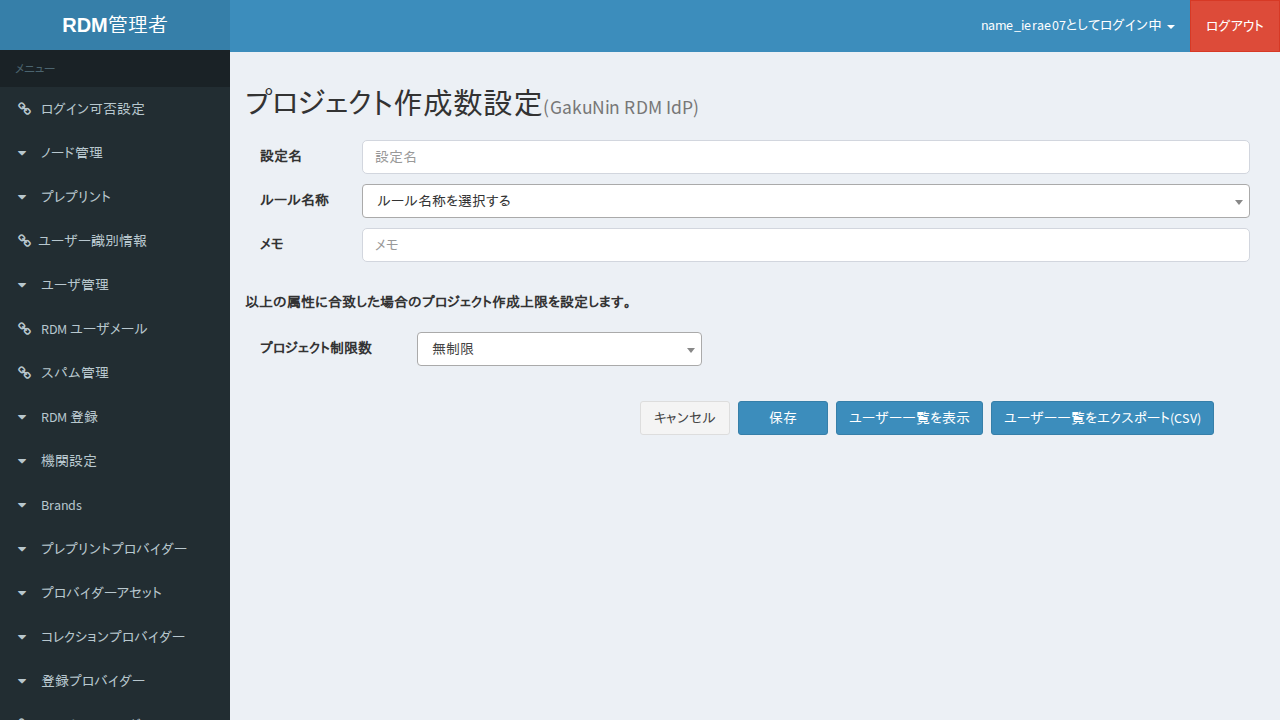

In [ ]:
async def _step(page):
    # 「新規作成」ボタンを押下
    await page.locator('a', has_text='新規作成').click()
    
    # 「プロジェクト作成数設定(XXXXX)」画面が表示されること
    await expect(page.locator('//h2[contains(.,"プロジェクト作成数設定")]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator(f'//h2/small[text()="({institution_name_project_limit_1})"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「設定名」に「setting4」、「ルール名称」のドロップダウンリストの中から「テンプレート作成・変更・削除」シートの No.22 で保存した「template1」、「メモ」に「memo4」を入力する

・「ルール名称」のドロップダウンリストの中に No.38 で「使用可否」を無効にした「template3」が表示されていないこと   
・「テンプレート作成・変更・削除」シートの No.22 で保存した「使用する属性」「値の設定方法」が表示されること   
・「使用する属性」「値の設定方法」「値」の中で「値」のみユーザが入力可能な状態になっていること   


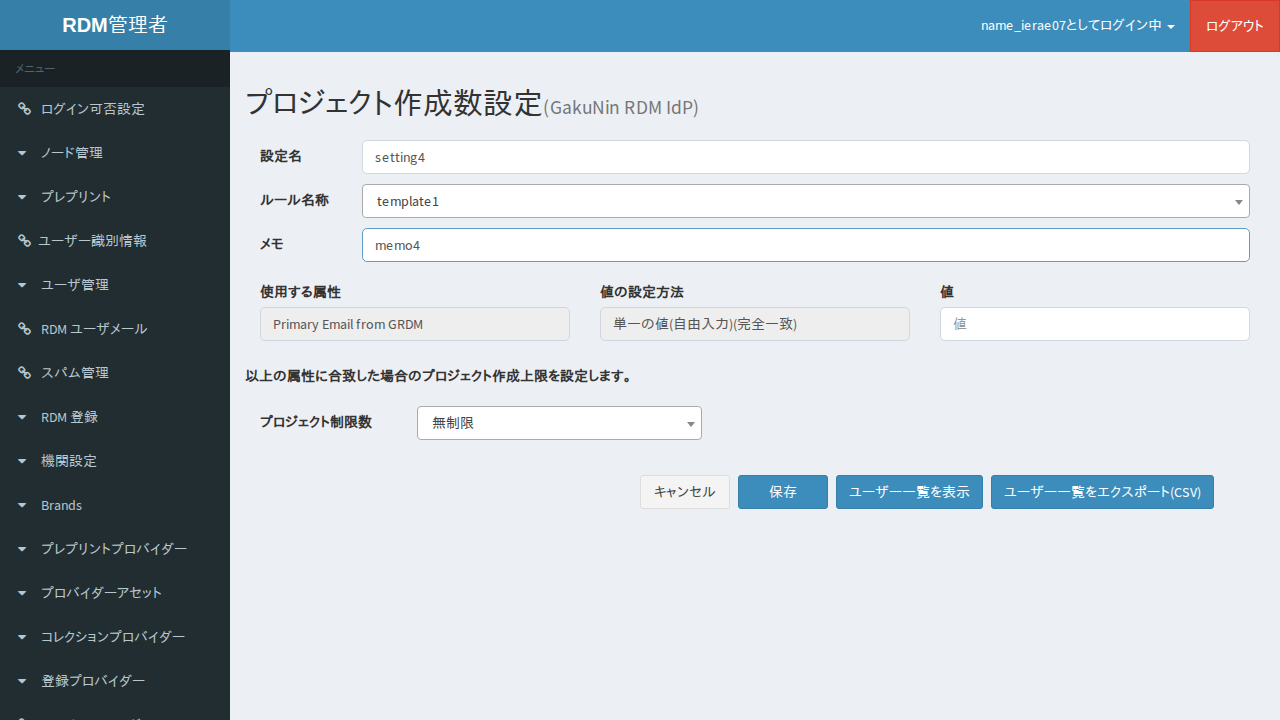

In [36]:
async def _step(page):
    # 「設定名」に「setting4」を入力
    await page.locator('#setting_name_id').fill('setting4')

    # 「ルール名称」で「template1」を選択
    await page.locator('#template_id').select_option(label='template1')

    # 「メモ」に「memo4」を入力
    await page.locator('#memo_id').fill('memo4')
    
    # 「ルール名称」のドロップダウンリストに「template3」が表示されていないことを確認
    await expect(page.locator('#template_id option', has_text='template3')).to_have_count(0, timeout=transition_timeout)

    # 「使用する属性」が表示されることを確認
    await expect(page.locator('//input[@name="attribute_name" and @value="Primary Email from GRDM"]')).to_be_visible(timeout=transition_timeout)

    # 「値の設定方法」が表示されることを確認
    await expect(page.locator('//input[@name="setting_name" and @value="単一の値(自由入力)(完全一致)"]')).to_be_visible(timeout=transition_timeout)

    # 「使用する属性」が入力不可であることを確認
    await expect(page.locator('//input[@name="attribute_name"]')).to_be_disabled(timeout=transition_timeout)

    # 「値の設定方法」が入力不可であることを確認
    await expect(page.locator('//input[@name="setting_name" and @value="単一の値(自由入力)(完全一致)"]')).to_be_disabled(timeout=transition_timeout)

    # 「値」のみ入力可能であることを確認
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_be_editable(timeout=transition_timeout)

await run_pw(_step)

## 「値」に「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」、「プロジェクト制限数」のドロップダウンリストの中から「1」を入力する

「値」に「テンプレート作成・変更・削除」シートの No.4 の「プライマリメール」、「プロジェクト制限数」に「1」が設定されること


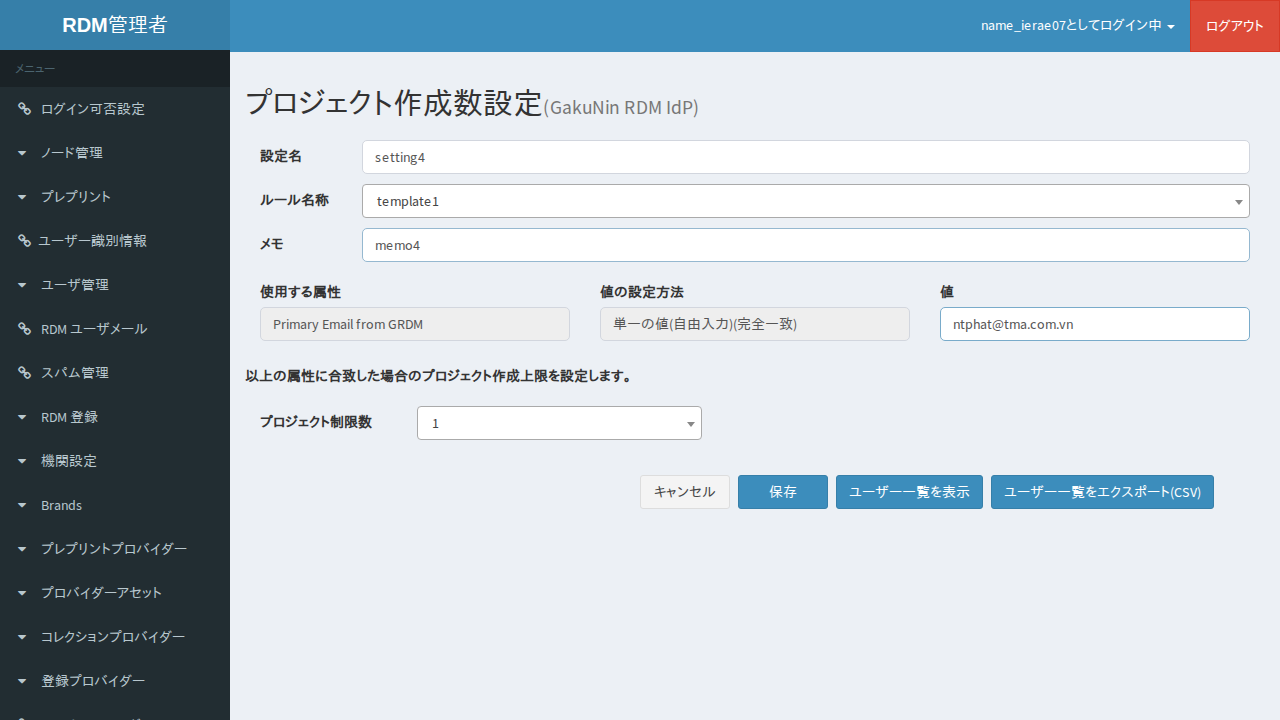

In [37]:
async def _step(page):
    # 「値」にプライマリメールを入力
    await page.locator('//input[@name="attribute_value_input"]').fill(primary_email)

    # 「プロジェクト制限数」で「1」を選択
    await page.locator('#project_limit_number_id').select_option('1')

    # 「値」が設定されていることを確認
    await expect(page.locator('//input[@name="attribute_value_input"]')).to_have_value(primary_email, timeout=transition_timeout)

    # 「プロジェクト制限数」が「1」であることを確認
    await expect(page.locator('#project_limit_number_id')).to_have_value('1', timeout=transition_timeout)

await run_pw(_step)

## 「保存」ボタンを押下する

「プロジェクト作成数設定一覧」画面に No.37 で設定した「設定名」「ルール名称」「メモ」が表示されること


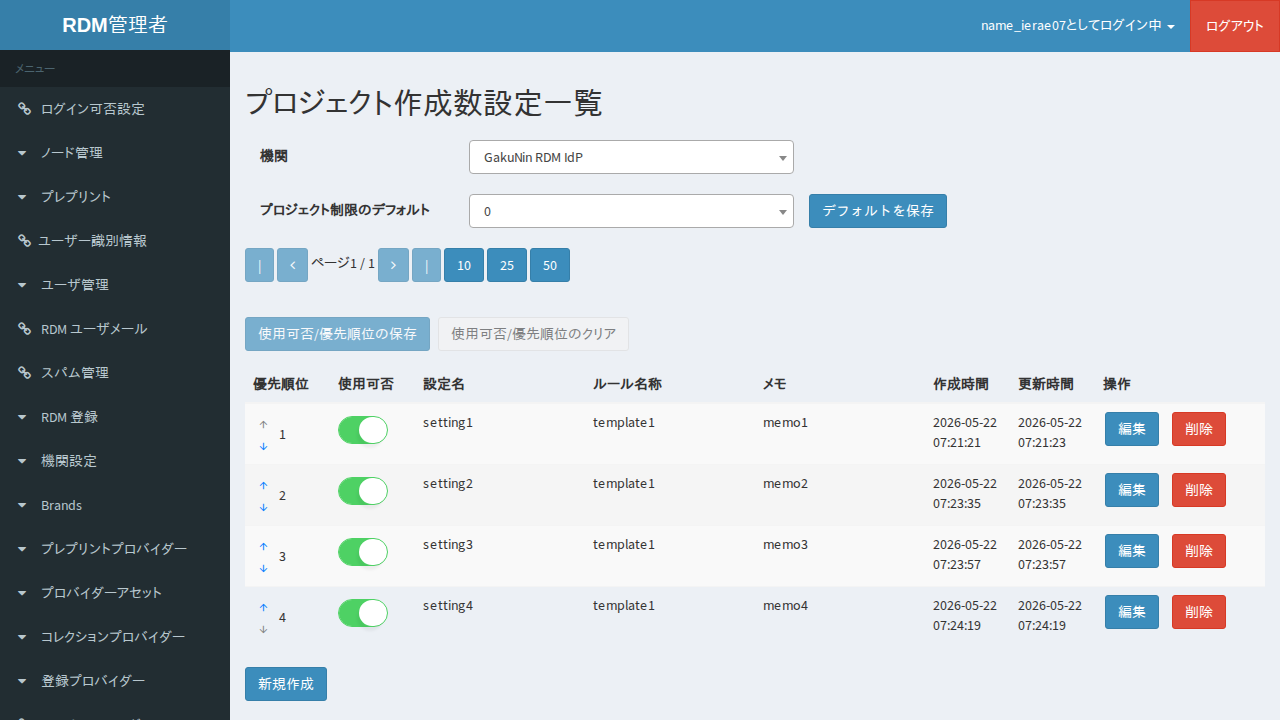

In [38]:
async def _step(page):
    # 「保存」ボタンを押下
    await page.locator('//button[@type="submit" and text()="保存"]').click()

    # 「プロジェクト作成数設定一覧」画面に遷移したことを確認
    await expect( page.locator('//h2[text()="プロジェクト作成数設定一覧"]')).to_be_visible(timeout=transition_timeout)

    # setting4 の行を取得
    row = page.locator('#setting-table tbody tr').filter(has_text='setting4')

    # 「設定名」「ルール名称」「メモ」が表示されることを確認
    await expect(row.locator('td').nth(2)).to_have_text('setting4', timeout=transition_timeout)
    await expect(row.locator('td').nth(3)).to_have_text('template1', timeout=transition_timeout)
    await expect(row.locator('td').nth(4)).to_have_text('memo4', timeout=transition_timeout)

await run_pw(_step)

## 「プロジェクト作成数設定一覧」画面でNo.27で作成した「設定名」の「setting2」の右端にある「削除」ボタンを押下する

「この設定を削除してもよろしいですか?」というメッセージが記載されたダイアログが表示されること


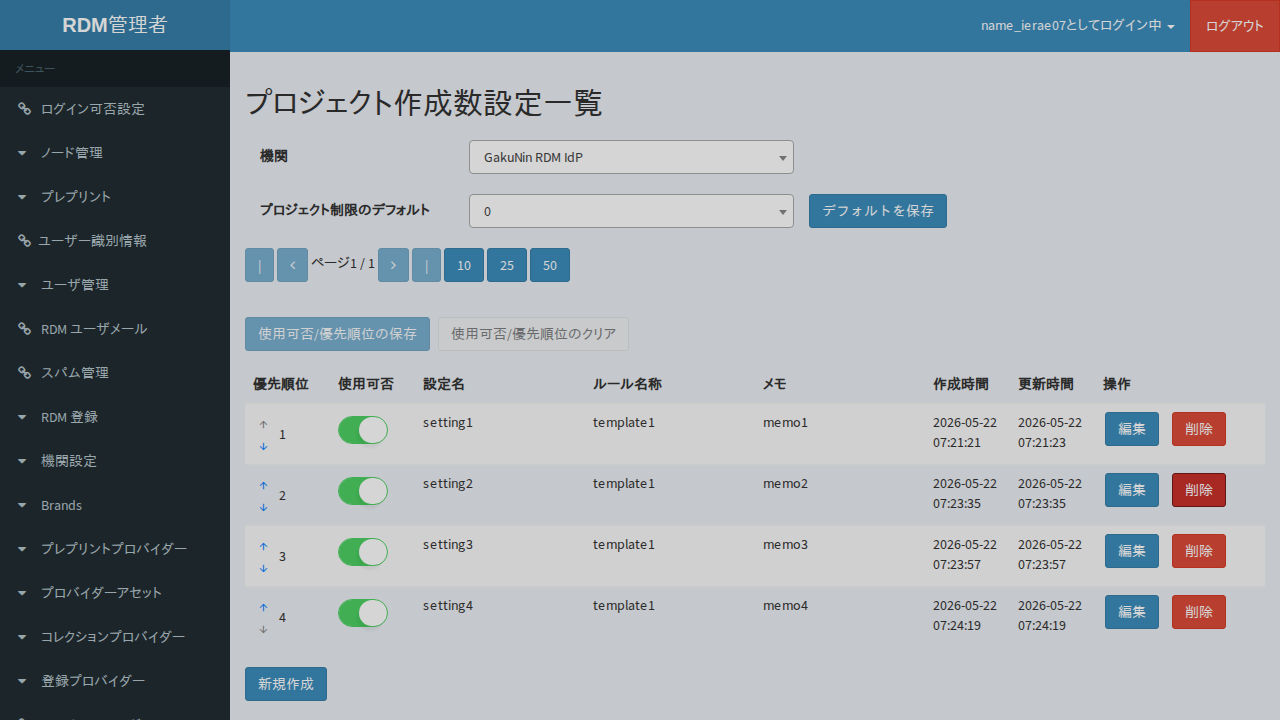

In [39]:
async def _step(page):
    # 「setting2」の削除ボタンを押下
    row = page.locator('#setting-table tbody tr').filter(has_text='setting2')
    await row.get_by_role('button', name='削除').click()
    
    # ダイアログメッセージ確認
    dialog = page.locator('#deleteSetting')
    await expect(dialog).to_contain_text( 'この設定を削除してもよろしいですか?',timeout=transition_timeout)

await run_pw(_step)

## 「確認」ボタンを押下する

「プロジェクト作成数設定一覧」画面で No.27 で作成した「設定名」の「setting2」の設定が削除されること


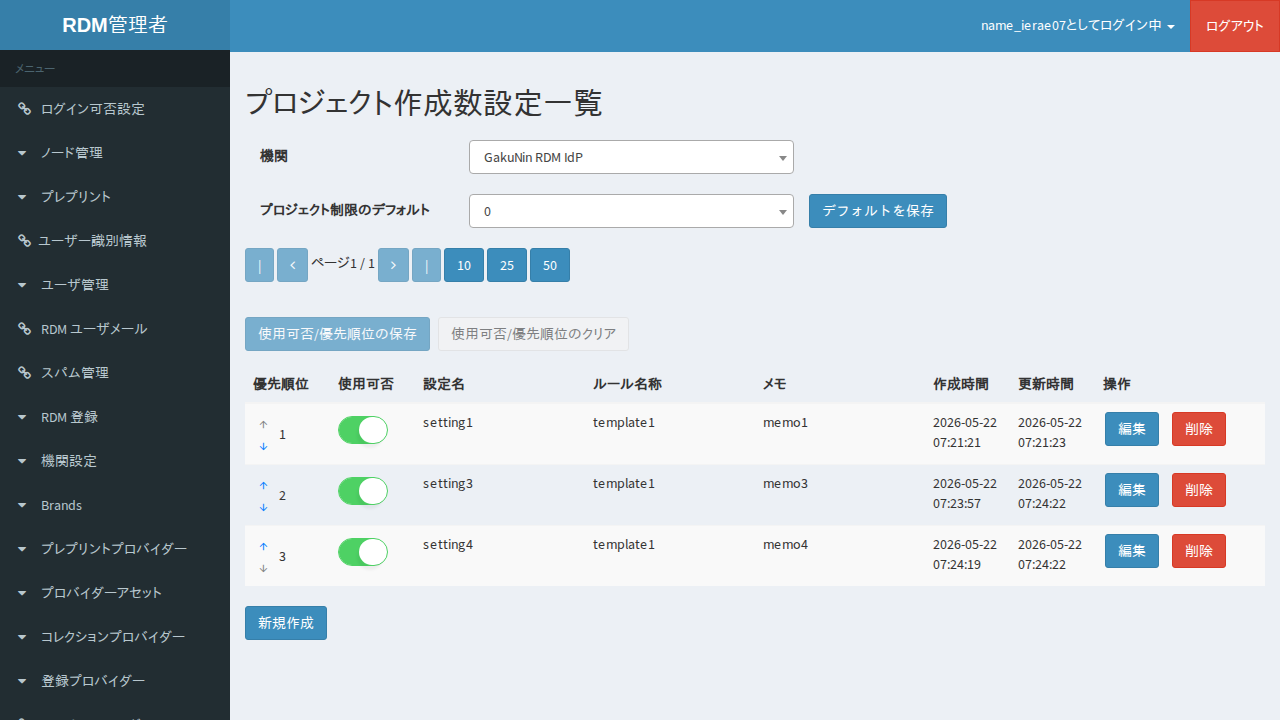

In [40]:
async def _step(page):
    # 「確認」ボタンを押下し、削除後の再読み込み完了を待機
    async with page.expect_navigation(wait_until='load', timeout=transition_timeout):
        await page.locator('#submitDeleteButton').click()

    # 「setting2」が一覧から削除されていることを確認
    await expect(page.locator('#setting-table tbody tr').filter(has_text='setting2')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## No.34 で保存した「設定名」の「setting3」の左にある「使用可否」のトグルボタンを押下する

「使用可否」のトグルボタンが変わり、「使用可否/優先順位の保存」と「使用可否/優先順位のクリア」が有効になること


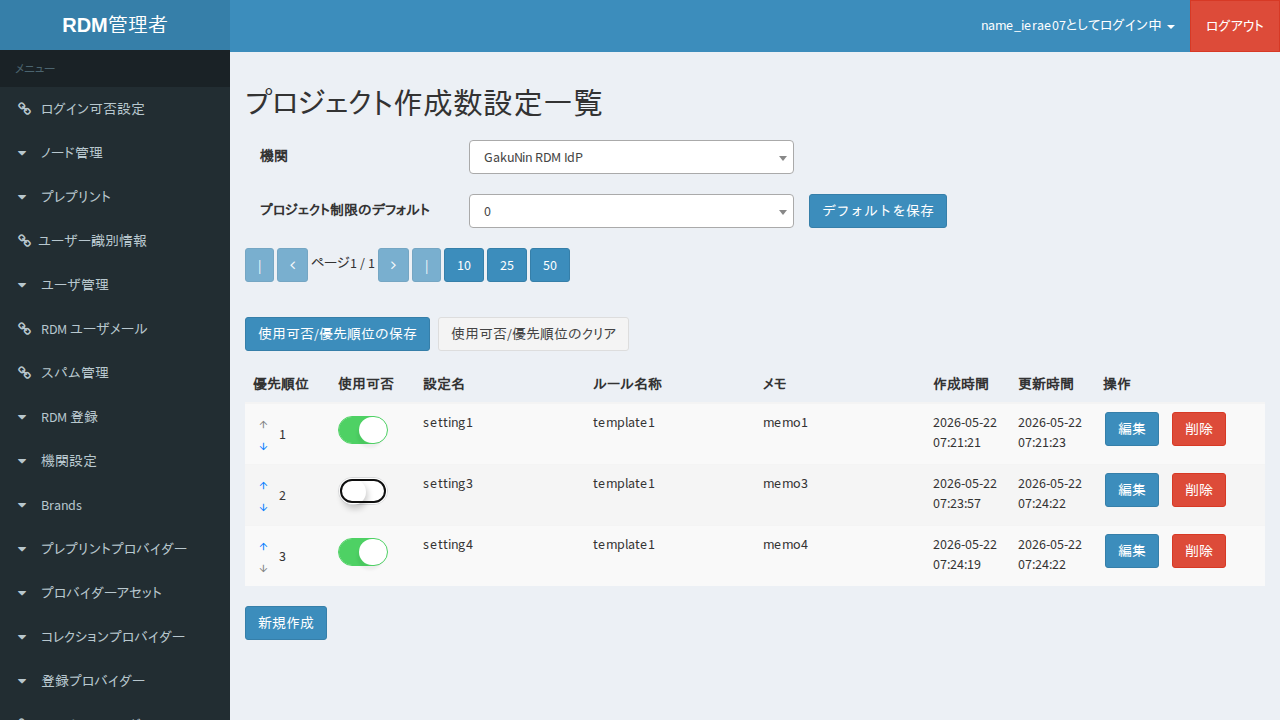

In [41]:
async def _step(page):
    # 「使用可否」のトグルボタンを押下
    row = page.locator('#setting-table tbody tr').filter(has_text='setting3')
    await row.locator('.setting-availability').click()

    # トグル状態が変更されること
    await expect(row.locator('.setting-availability')).to_have_value('off', timeout=transition_timeout)

    # 「使用可否/優先順位の保存」が有効になること
    await expect(page.locator('#save_changes_button')).to_be_enabled(timeout=transition_timeout)

    # 「使用可否/優先順位のクリア」が有効になること
    await expect(page.locator('#clear_changes_button')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## No.39 で保存した「設定名」の「setting4」の左端にある優先順位の「↑」を 2 回クリックする

「設定名」の「setting4」の「優先順位」が「1」になること


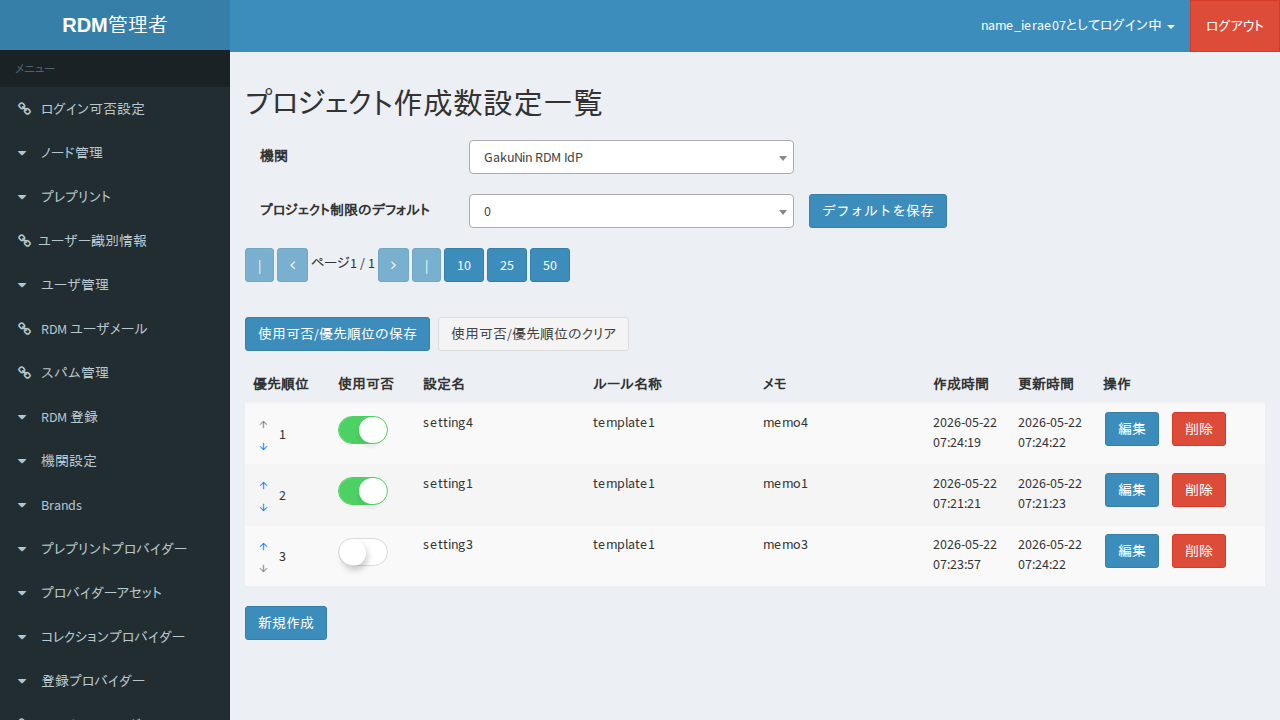

In [42]:
async def _step(page):
    # 「setting4」の「↑」を2回クリック
    row = page.locator('#setting-table tbody tr').filter(has_text='setting4')
    await row.locator('button.up').click()
    await row.locator('button.up').click()

    # 「setting4」の優先順位が「1」になっていることを確認
    await expect(row.locator('.setting-priority')).to_have_text('1', timeout=transition_timeout)

await run_pw(_step)

## 「使用可否/優先順位のクリア」ボタンを押下する

No.44 の「使用可否」のトグルボタンとNo.45 の「優先順位」が変更前の状態に戻ること


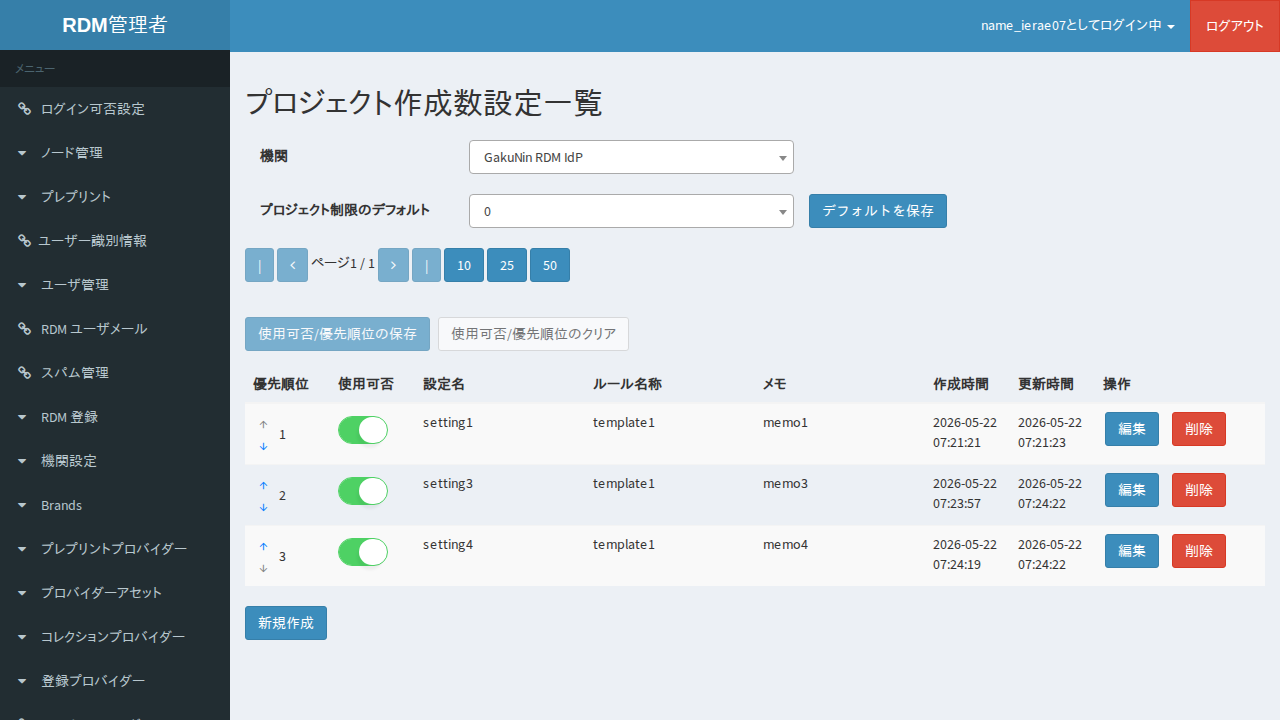

In [43]:
async def _step(page):
   # 「使用可否/優先順位のクリア」を押下
    await page.locator('#clear_changes_button').click()

    # 「setting3」の使用可否が元の ON に戻ること
    row_setting3 = page.locator('#setting-table tbody tr').filter(has_text='setting3')
    await expect(row_setting3.locator('.setting-availability')).to_have_value('on', timeout=transition_timeout)

    # 「setting4」の優先順位が元の「3」に戻ること
    row_setting4 = page.locator('#setting-table tbody tr').filter(has_text='setting4')
    await expect(row_setting4.locator('.setting-priority')).to_have_text('3', timeout=transition_timeout)

await run_pw(_step)

## No.34 で保存した「設定名」の「setting3」の左にある「使用可否」のトグルボタンを再び押下する

「使用可否」のトグルボタンが変わり、「使用可否/優先順位の保存」と「使用可否/優先順位のクリア」が有効になること


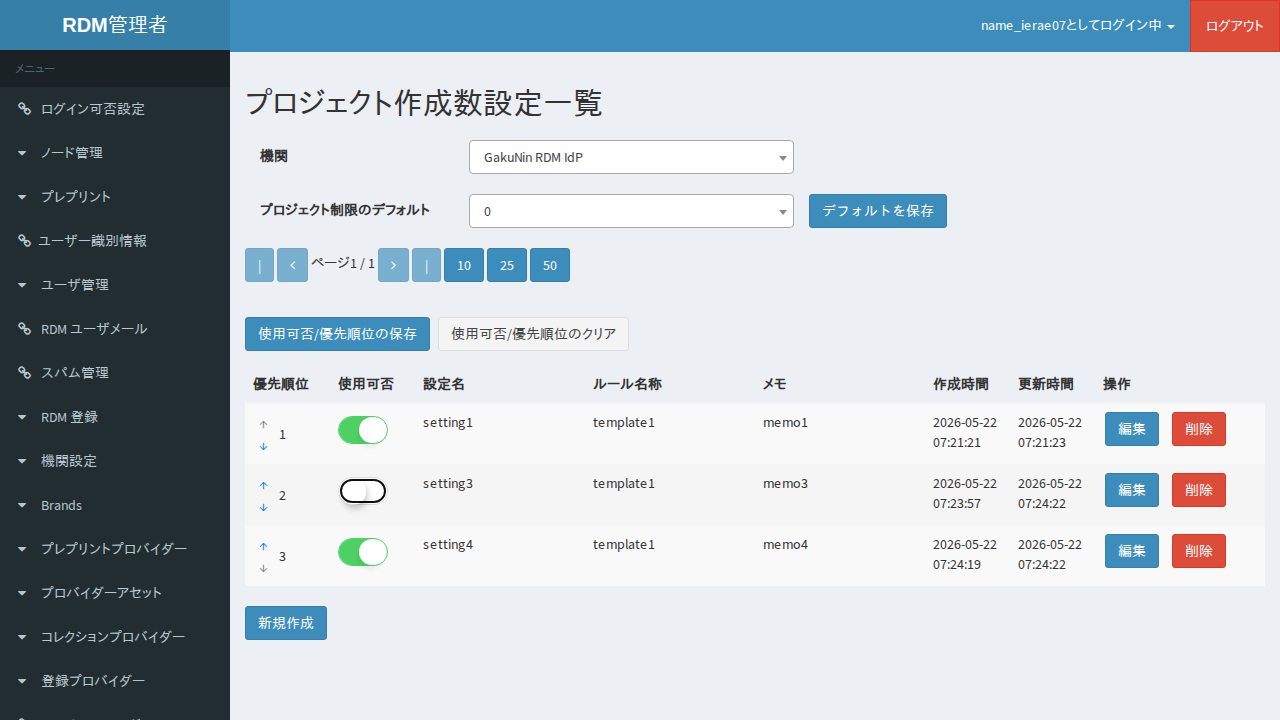

In [44]:
async def _step(page):
    # 「使用可否」のトグルボタンを押下
    row = page.locator('#setting-table tbody tr').filter(has_text='setting3')
    await row.locator('.setting-availability').click()

    # トグル状態が変更されること
    await expect(row.locator('.setting-availability')).to_have_value('off', timeout=transition_timeout)

    # 「使用可否/優先順位の保存」が有効になること
    await expect(page.locator('#save_changes_button')).to_be_enabled(timeout=transition_timeout)

    # 「使用可否/優先順位のクリア」が有効になること
    await expect(page.locator('#clear_changes_button')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## No.39 で保存した「設定名」の「setting4」の左端にある優先順位の「↑」を再び 2 回クリックする

「設定名」の「setting4」の「優先順位」が「1」になること


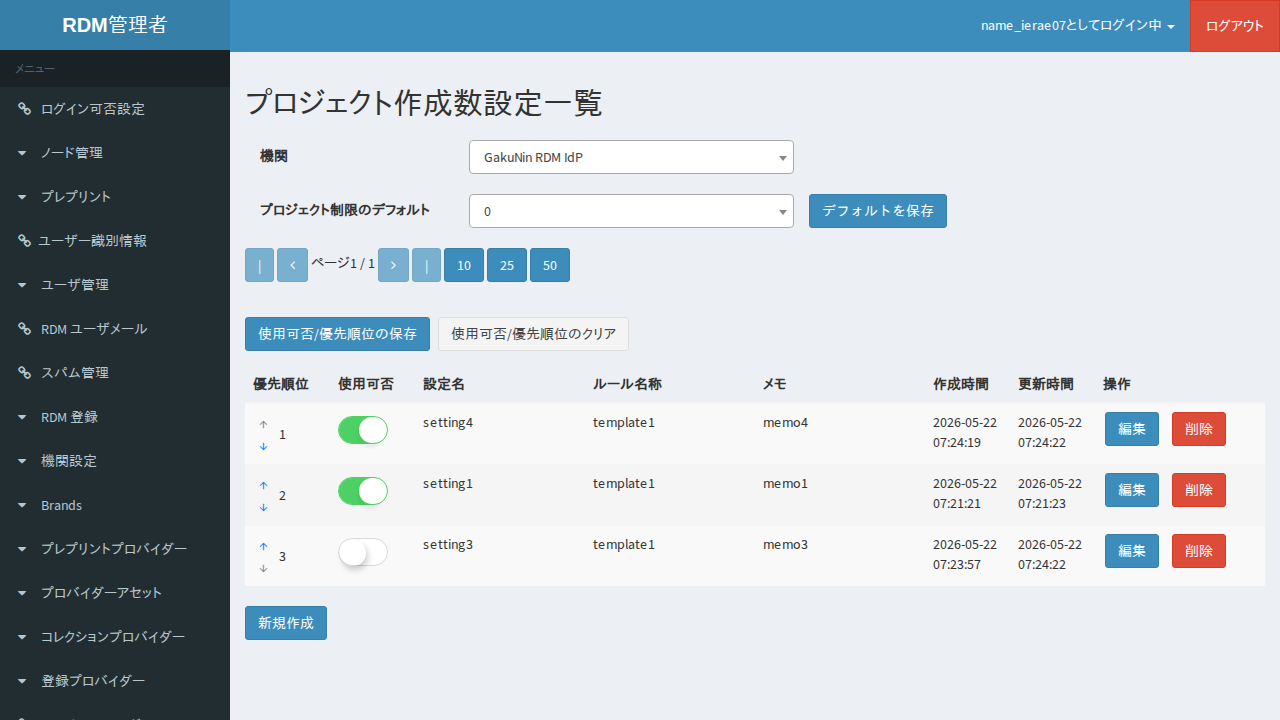

In [45]:
async def _step(page):
    # 「setting4」の「↑」を2回クリック
    row = page.locator('#setting-table tbody tr').filter(has_text='setting4')
    await row.locator('button.up').click()
    await row.locator('button.up').click()

    # 「setting4」の優先順位が「1」になっていることを確認
    await expect(row.locator('.setting-priority')).to_have_text('1', timeout=transition_timeout)

await run_pw(_step)

## 「使用可否/優先順位の保存」ボタンを押下する

No.47 の「使用可否」のトグルボタンとNo.48 の「優先順位」が確定し、「使用可否/優先順位の保存」と「使用可否/優先順位のクリア」が無効になること


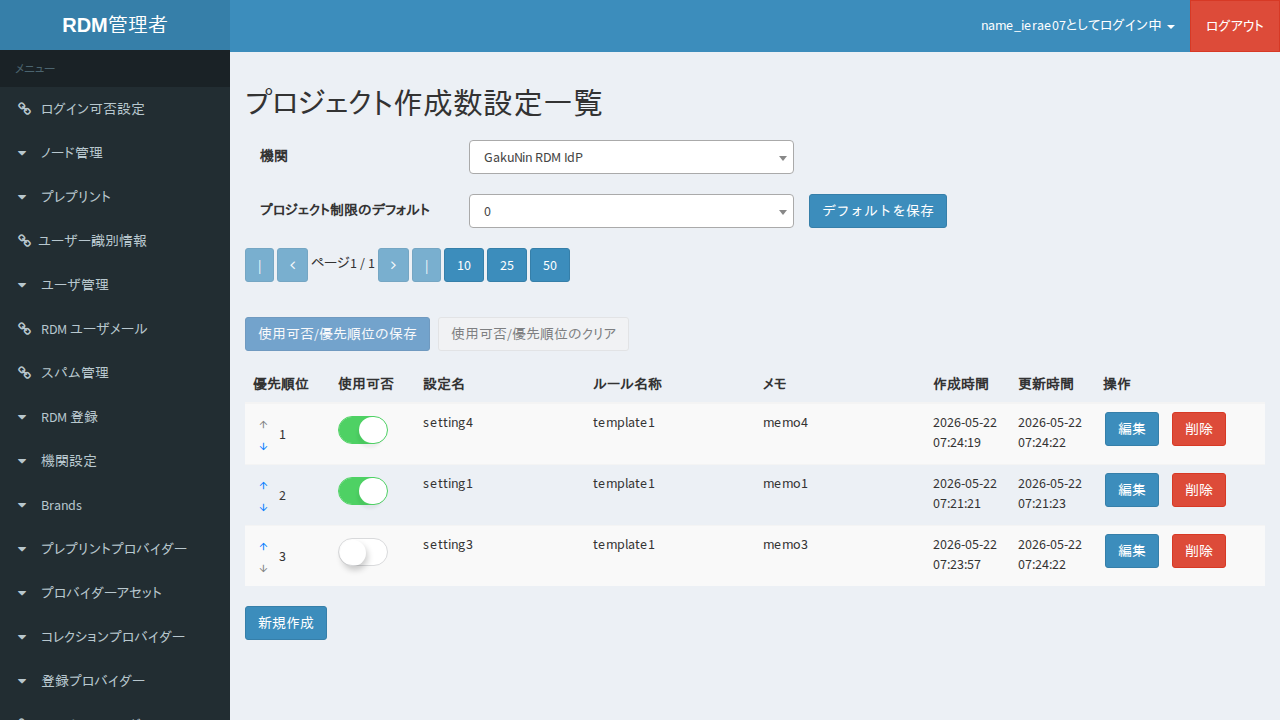

In [46]:
async def _step(page):
   # 「使用可否/優先順位の保存」を押下し、保存後の再読み込み完了を待機
    async with page.expect_navigation(wait_until='load', timeout=transition_timeout):
        await page.locator('#save_changes_button').click()

    # 「setting3」の使用可否が確定していること（OFF）
    row_setting3 = page.locator('#setting-table tbody tr').filter(has_text='setting3')
    await expect(row_setting3.locator('.setting-availability')).to_have_value('off', timeout=transition_timeout)

    # 「setting4」の優先順位が確定していること（1）
    row_setting4 = page.locator('#setting-table tbody tr').filter(has_text='setting4')
    await expect(row_setting4.locator('.setting-priority')).to_have_text('1', timeout=transition_timeout)

    # 「使用可否/優先順位の保存」が無効になること
    await expect(page.locator('#save_changes_button')).to_be_disabled(timeout=transition_timeout)

    # 「使用可否/優先順位のクリア」が無効になること
    await expect(page.locator('#clear_changes_button')).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

終了処理を実施。

In [ ]:
await finish_pw_context()

In [ ]:
!rm -fr {work_dir}